In [382]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import seaborn as sns
import yaml
from pathlib import Path

# Load the data

In [383]:
# TODO: implement a measure of attempted rent that accounts for the differences in the possible set between buyers and seller (buyers are bounded from both sides, sellers are not) 

In [384]:
# select the experiment for which you want to analyse data
# experiment_id = "smith1_20260211_220938"
# experiment_id = "smith2_20260211_221148"
# experiment_id = "smith3_20260211_221154"
# experiment_id = "smith4a_20260211_224556"
# experiment_id = "smith6a_20260211_221213"
# experiment_id = "smith1_20260218_193842" # openAI
# experiment_id = "smith1_flash_t0_20260228_173740"
# experiment_id = "smith1_flash_t1_20260228_173738"
# experiment_id = "smith1_flash_t2_20260228_173740"
# experiment_id = "smith1_pro_t1_20260228_150742"
# experiment_id = "smith1_pro_t1_noreason_20260228_150742"
# experiment_id = "smith2_flash_t0_20260228_173738"
# experiment_id = "smith2_flash_t1_20260228_173739"
# experiment_id = "smith2_flash_t2_20260228_173740"
# experiment_id = "smith2_pro_t1_20260228_150742"
# experiment_id = "smith2_pro_t1_noreason_20260228_150742"
# experiment_id = "smith3_flash_t0_20260228_173736"
# experiment_id = "smith3_flash_t1_20260228_173738"
# experiment_id = "smith3_flash_t2_20260228_173739"
# experiment_id = "smith3_pro_t1_20260228_150742"
# experiment_id = "smith3_pro_t1_noreason_20260228_150742"
# experiment_id = "smith4a_flash_t0_20260228_173740"
# experiment_id = "smith4a_flash_t1_20260228_173738"
# experiment_id = "smith4a_flash_t2_20260228_173740"
# experiment_id = "smith4a_pro_t1_20260228_150742"
# experiment_id = "smith4a_pro_t1_noreason_20260228_150742"
# experiment_id = "smith6a_flash_t0_20260228_173738"
# experiment_id = "smith6a_flash_t1_20260228_173739"
# experiment_id = "smith6a_flash_t2_20260228_173738"
# experiment_id = "smith6a_pro_t1_20260228_150742"
# experiment_id = "smith6a_pro_t1_noreason_20260228_150742"
# experiment_id = "smith7_flash_t0_20260228_173740"
# experiment_id = "smith7_flash_t1_20260228_173737"
# experiment_id = "smith7_flash_t2_20260228_173739"
# experiment_id = "smith7_pro_t1_20260228_150742"
# experiment_id = "smith7_pro_t1_noreason_20260228_150742"

# experiment_id = "smith1_t1_openai_20260324_232624"
# experiment_id = "smith1_t1_openai_personas_men_20260326_002549"
# experiment_id = "smith1_t1_openai_personas_women_20260325_214736"
experiment_id = "smith1_t1_openai_personas_diverse_20260326_123803"

In [385]:
root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# collect only simulations where both files exist
available_sims = [
    sim for sim in range(1, n_sims + 1)
    if (results_path / 'data' / f'iteration_history_{sim}.csv').exists()
    and (results_path / 'data' / f'agent_histories_{sim}.csv').exists()
]

# read the results data for all available simulations
iteration_histories = [pd.read_csv(results_path / 'data' / f'iteration_history_{sim}.csv')
                       for sim in available_sims]

agents_histories = [pd.read_csv(results_path / 'data' / f'agent_histories_{sim}.csv')
                    for sim in available_sims]

# combine multiple simulations into a single dataframe
df_data_all = pd.concat(
    [df.assign(sim=sim) for df, sim in zip(iteration_histories, available_sims)],
    ignore_index=True
)
df_data_agents_all = pd.concat(
    [df.assign(sim=sim) for df, sim in zip(agents_histories, available_sims)],
    ignore_index=True
)

# Calculate the Equilibrium Price/Quantity for the experiment

In [386]:
def find_equilibrium(supply, demand, flat_threshold=1e-10):
    """
    Find equilibrium quantity and price where demand >= supply.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        flat_threshold: tolerance for considering a curve "flat"
    
    Returns:
        q_eq: equilibrium quantity (number of trades)
        p_eq: equilibrium price
        p_supply: supply price at last trade
        p_demand: demand price at last trade
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    n = min(len(supply), len(demand))
    
    # Find last index where demand >= supply
    viable_mask = demand[:n] >= supply[:n]
    
    if not viable_mask.any():
        return 0, None, None, None
    
    last_idx = np.flatnonzero(viable_mask)[-1]
    next_idx = last_idx + 1
    
    q_eq = last_idx + 1
    p_supply = supply[last_idx]
    p_demand = demand[last_idx]
    
    # Check what happens at the next quantity unit
    has_next_supply = next_idx < len(supply)
    has_next_demand = next_idx < len(demand)
    
    # Determine price based on curve behavior at equilibrium
    if not has_next_supply:
        # Supply is vertical (ran out) - price based on demand side
        p_eq = (p_demand + demand[next_idx]) / 2 if has_next_demand else p_demand
    elif not has_next_demand:
        # Demand is vertical (ran out) - price based on supply side
        p_eq = (p_supply + supply[next_idx]) / 2 if has_next_supply else p_supply
    elif abs(supply[next_idx] - p_supply) < flat_threshold:
        # Supply is flat (perfectly elastic) - use supply price
        p_eq = p_supply
    elif abs(demand[next_idx] - p_demand) < flat_threshold:
        # Demand is flat (perfectly elastic) - use demand price
        p_eq = p_demand
    else:
        # Both curves have slope - use midpoint
        p_eq = (p_supply + p_demand) / 2
    
    return q_eq, p_eq

In [387]:
def plot_equilibrium(supply, demand, q_eq, p_eq, title=None, ax=None):
    """
    Visualize supply and demand curves with equilibrium point.
    
    Parameters:
        supply: array of supply prices at each quantity
        demand: array of demand prices at each quantity
        q_eq: equilibrium quantity
        p_eq: equilibrium price
        title: optional plot title
        ax: optional matplotlib axes (creates new figure if None)
    
    Returns:
        matplotlib axes object
    """
    supply = np.asarray(supply)
    demand = np.asarray(demand)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    quantities_supply = np.arange(len(supply)) + 1
    quantities_demand = np.arange(len(demand)) + 1
    
    ax.step(quantities_supply, supply, 'r-', where='pre', label='Supply', linewidth=2)
    ax.step(quantities_demand, demand, 'b-', where='pre', label='Demand', linewidth=2)
    
    y_max = max(supply[-1], demand[0]) * 1.2
    
    # Extend supply vertically upward
    ax.vlines(len(supply), supply[-1], y_max, colors='red', linewidth=2)
    
    # Extend demand vertically downward
    ax.vlines(len(demand), demand[-1], 0, colors='blue', linewidth=2)
    
    if q_eq > 0 and p_eq is not None:
        ax.plot(q_eq, p_eq, 'go', markersize=12,
                label=f'Equilibrium: Q={q_eq}, P={p_eq:.2f}', zorder=5)
        ax.axhline(p_eq, color='green', linestyle=':', alpha=0.5, linewidth=1.5)
        ax.axvline(q_eq, color='green', linestyle='--', alpha=0.5, linewidth=1.5)
    
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_title(title or 'Supply and Demand - Equilibrium')
    ax.set_ylim(0, y_max)
    
    return ax


In [388]:
# extract the demand and supply schedules from the config
demand = np.round(
    np.linspace(
        config["experiment"]["buyers"]["max"],
        config["experiment"]["buyers"]["min"],
        config["experiment"]["buyers"]["num"],
    ),
    2,
)
supply = np.round(
    np.linspace(
        config["experiment"]["sellers"]["min"],
        config["experiment"]["sellers"]["max"],
        config["experiment"]["sellers"]["num"],
    ),
    2,
)
# calculate the equilibrium price and quantity
q_eq, p_eq = find_equilibrium(supply=supply, demand=demand)
print(f"Equilibrium quantity: {q_eq}")
print(f"Equilibrium price: ${p_eq}")

# store in the results dataframe
df_data_all["equilibrium_price"] = p_eq
df_data_all["equilibrium_quantity"] = q_eq

Equilibrium quantity: 6
Equilibrium price: $2.0


<Axes: title={'center': 'Supply and Demand - Equilibrium'}, xlabel='Quantity', ylabel='Price'>

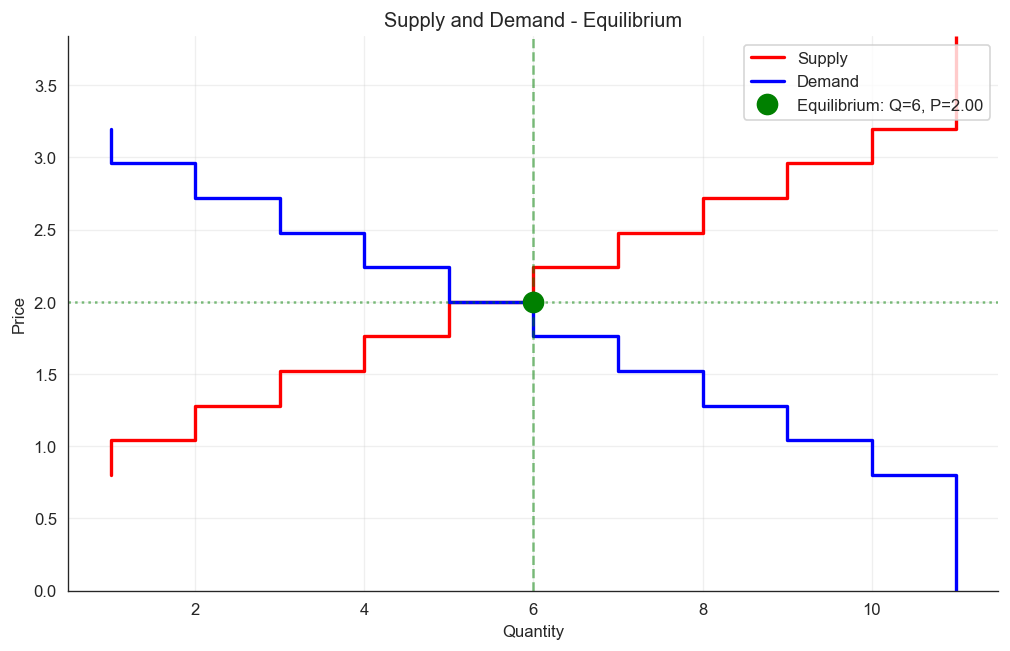

In [389]:
# plot the supply and demand curves and show the equilibrium
plot_equilibrium(supply, demand, q_eq, p_eq)

# Convergence Analysis

## Convergence to Theoretical Equilibrium

In [ ]:
# Smith (1962) "An Experimental Study of Competitive Market Behavior"
# All values from Table 1
# Keys: experiment name -> {round_number: value}
 
# Coefficient of convergence: alpha = 100 * sigma_0 / P0
# where sigma_0 = std of exchange prices around equilibrium price (not around mean)
smith_alpha = {
    "smith1": {1: 11.8, 2: 8.1, 3: 5.2, 4: 5.5, 5: 3.5},
    "smith2": {1: 9.9, 2: 5.4, 3: 2.2},
    "smith3": {1: 16.5, 2: 6.6, 3: 3.7, 4: 5.7},
    "smith4a": {1: 19.1, 2: 10.4, 3: 7.8, 4: 7.6},
    "smith4b": {1: 6.9, 2: 7.1, 3: 6.5},
    "smith5a": {1: 2.0, 2: 0.7, 3: 0.7, 4: 0.6},
    "smith5b": {1: 9.4, 2: 4.3},
    "smith6a": {1: 53.8, 2: 38.7, 3: 21.1, 4: 9.4},
    "smith6b": {1: 11.0},
    "smith7": {1: 49.1, 2: 22.2, 3: 7.1, 4: 5.4, 5: 3.0, 6: 2.7},
    "smith8a": {1: 19.0, 2: 2.9, 3: 7.4, 4: 7.0},
    "smith8b": {1: 7.8, 2: 6.1},
    "smith9a": {1: 21.8, 2: 15.4, 3: 13.2},
    "smith9b": {1: 10.3},
    "smith10": {1: 11.0, 2: 3.2, 3: 2.2},
}

In [390]:
# Smith (1962) "An Experimental Study of Competitive Market Behavior"
# All values from Table 1
# Keys: experiment name -> {round_number: value}
 
# Coefficient of convergence: alpha = 100 * sigma_0 / P0
# where sigma_0 = std of exchange prices around equilibrium price (not around mean)
smith_alpha = {
    "smith1": {1: 11.8, 2: 8.1, 3: 5.2, 4: 5.5, 5: 3.5},
    "smith2": {1: 9.9, 2: 5.4, 3: 2.2},
    "smith3": {1: 16.5, 2: 6.6, 3: 3.7, 4: 5.7},
    "smith4a": {1: 19.1, 2: 10.4, 3: 7.8, 4: 7.6},
    "smith4b": {1: 6.9, 2: 7.1, 3: 6.5},
    "smith5a": {1: 2.0, 2: 0.7, 3: 0.7, 4: 0.6},
    "smith5b": {1: 9.4, 2: 4.3},
    "smith6a": {1: 53.8, 2: 38.7, 3: 21.1, 4: 9.4},
    "smith6b": {1: 11.0},
    "smith7": {1: 49.1, 2: 22.2, 3: 7.1, 4: 5.4, 5: 3.0, 6: 2.7},
    "smith8a": {1: 19.0, 2: 2.9, 3: 7.4, 4: 7.0},
    "smith8b": {1: 7.8, 2: 6.1},
    "smith9a": {1: 21.8, 2: 15.4, 3: 13.2},
    "smith9b": {1: 10.3},
    "smith10": {1: 11.0, 2: 3.2, 3: 2.2},
}

In [391]:
def calculate_coefficient_of_convergence(prices: np.ndarray, equilibrium_price: float):
    """Calculates the coefficient of convergene of prices to equilibrium (alpha) from the Smith (1962) paper.
    
    Parameters:
        prices: array of prices within a round
        equilibrium_price: theoretical equilibrium price    
    Returns:
        alpha: coefficient of convergene
    """
    squared_deviations = (prices - equilibrium_price)**2 
    var = squared_deviations.sum()/len(prices)
    std = var**0.5
    alpha = 100*std/equilibrium_price
    return alpha

df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
coefficients_of_convergence = df_transactions_all.groupby(['sim', 'round'])['price'].agg(
    lambda prices: calculate_coefficient_of_convergence(prices.values, equilibrium_price=p_eq)
).reset_index(name='coefficient_of_convergence')
smith_key = experiment_id.split('_')[0]
coefficients_of_convergence['smith'] = coefficients_of_convergence['round'].map(smith_alpha[smith_key])

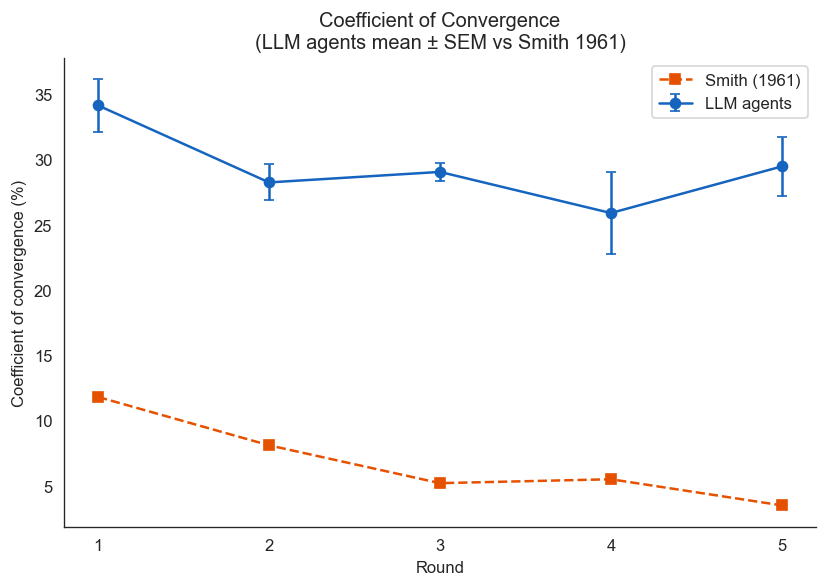

In [392]:
# ============================================================
# Coefficient of Convergence: LLM simulations vs Smith (1961)
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

# LLM simulations (mean ± SEM across sims)
sr = coefficients_of_convergence.groupby('round')['coefficient_of_convergence'].agg(['mean', 'sem'])
ax.errorbar(sr.index, sr['mean'], yerr=sr['sem'],
            fmt='-o', color='#1565C0', capsize=3, markersize=6, label='LLM agents')

# Smith (1961) — one value per round, no error bars
smith_vals = coefficients_of_convergence.drop_duplicates('round')[['round', 'smith']].dropna()
ax.plot(smith_vals['round'], smith_vals['smith'],
        '--s', color='#E65100', markersize=6, label='Smith (1961)')

ax.set_xlabel('Round')
ax.set_ylabel('Coefficient of convergence (%)')
ax.set_title('Coefficient of Convergence\n(LLM agents mean ± SEM vs Smith 1961)')
ax.set_xticks(sorted(coefficients_of_convergence['round'].unique()))
ax.legend()
plt.tight_layout()
plt.show()

### Single Simulation Graph, Smith (1962)

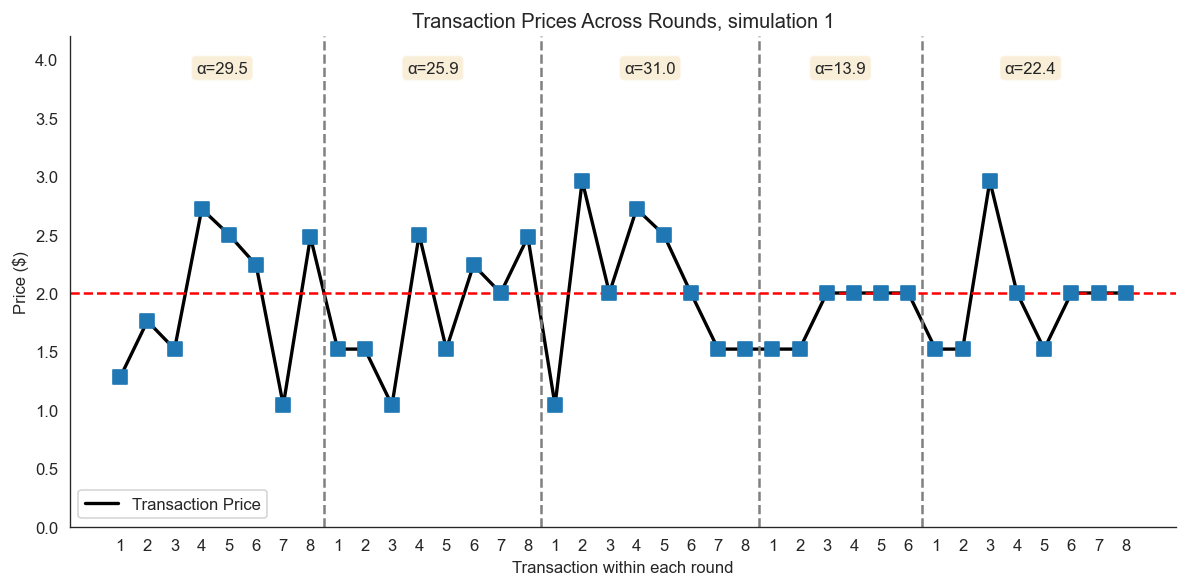

In [393]:
# choose a simulation to plot
sim = 1

df_plot = df_data_all.loc[df_data_all['sim']==sim]
df_plot = df_plot[df_plot['transaction_made'] == True].reset_index()
df_plot['transaction_number'] = df_plot.groupby('round').cumcount() + 1

plt.figure(figsize=(10, 5))
# --- Line connecting all transactions ---
if len(df_plot) > 0:
    plt.plot(
        df_plot.index,
        df_plot['price'], 
        color='black',
        linewidth=2,
        label='Transaction Price',
        zorder=2
    )

    # --- markers ---
    plt.scatter(
        df_plot.index, 
        df_plot['price'], 
        marker='s', 
        s=80,
        color='#1f77b4',
        zorder=3
    )

# --- Dynamic axis limits ---
y_min = np.max([np.concat([supply, demand]).min() - 1, 0])
y_max = np.concat([supply, demand]).max() + 1
y_range = y_max - y_min
alpha_y_pos = y_max - 0.05 * y_range  # position alpha labels near top

# --- Formatting ---
last_indices_in_round = df_plot.groupby('round')['transaction_number'].apply(lambda g: g.index.max())
for x in last_indices_in_round[:-1]:
    plt.axvline(x=x+0.5, color='grey', linestyle='--', linewidth=1.5)

# --- Add alpha values for each round ---
rounds = df_plot['round'].unique()
first_indices = df_plot.groupby('round').apply(lambda g: g.index.min(), include_groups=False)
for i, round_num in enumerate(rounds):
    if i == 0:
        start_pos = first_indices.iloc[i]
    else:
        start_pos = last_indices_in_round.iloc[i-1] + 0.5
    
    if i < len(last_indices_in_round):
        end_pos = last_indices_in_round.iloc[i] + 0.5
    else:
        end_pos = df_plot.index.max()
    
    mid_pos = (start_pos + end_pos) / 2
    alpha_value = coefficients_of_convergence.loc[
        (coefficients_of_convergence["sim"]==sim) & 
        (coefficients_of_convergence["round"]==round_num), 
        "coefficient_of_convergence"
    ].values[0]
    
    plt.text(mid_pos, alpha_y_pos, f'α={alpha_value:.1f}', 
             ha='center', va='top', fontsize=10, 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.axhline(y=p_eq, color='red', linestyle='--')
plt.xticks(ticks=df_plot.index, labels=df_plot['transaction_number'], rotation=0)
plt.title(f'Transaction Prices Across Rounds, simulation {sim}')
plt.xlabel('Transaction within each round')
plt.ylabel('Price ($)')
plt.ylim(y_min, y_max)
plt.legend()
plt.tight_layout()
plt.show()

### Multiple Simulations Convergence Overview

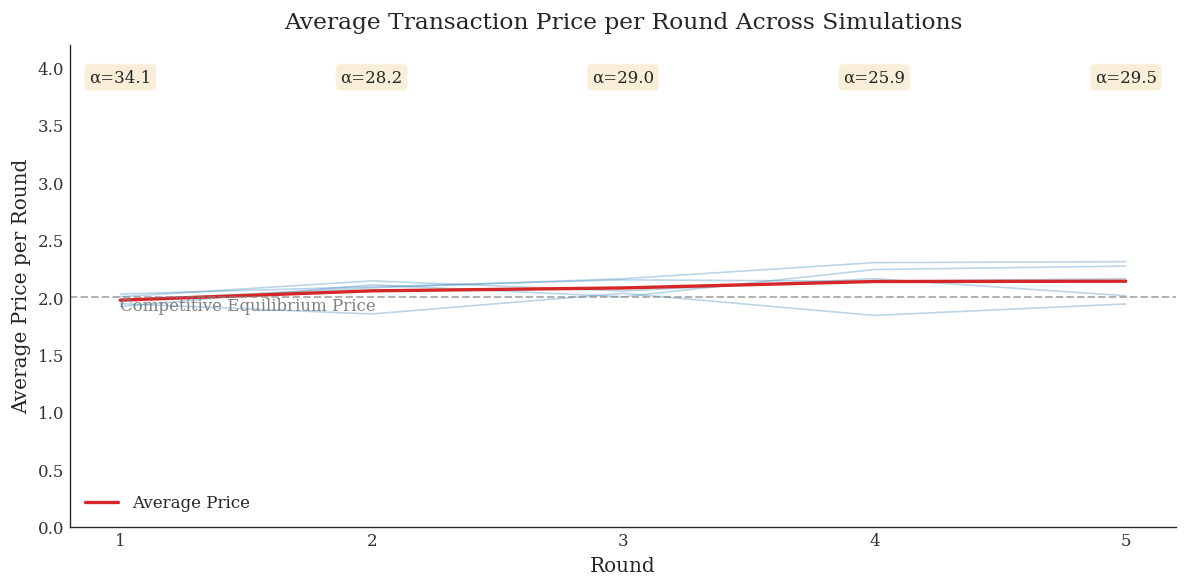

In [394]:
df_transactions_all = df_data_all.loc[df_data_all['transaction_made']==True].reset_index()
sim_round_avg = df_transactions_all.groupby(['sim', 'round'])['price'].agg(['mean', 'std', 'count']).reset_index()
df_plot = sim_round_avg.pivot_table(index='round', columns='sim', values='mean')

# --- Compute average alpha per round across simulations ---
avg_alpha = (
    coefficients_of_convergence
    .groupby('round')['coefficient_of_convergence']
    .mean()
)

fig, ax = plt.subplots(figsize=(10,5))

sim_color = '#1f77b4'
avg_color = '#d62728'

# --- Dynamic axis limits ---
y_min = np.max([np.concat([supply, demand]).min() - 1, 0])
y_max = np.concat([supply, demand]).max() + 1
y_range = y_max - y_min
alpha_y_pos = y_max - 0.05 * y_range  # position alpha labels near top

for sim_id in df_plot.columns:
    ax.plot(df_plot.index, df_plot[sim_id], color=sim_color, alpha=0.3, linewidth=1)

avg_prices = df_plot.mean(axis=1)
ax.plot(df_plot.index, avg_prices, color=avg_color, linewidth=2, label='Average Price')

ax.axhline(y=p_eq, color='grey', linestyle='--', linewidth=1.2, alpha=0.6)
ax.text(df_plot.index[0], p_eq - 0.15, 'Competitive Equilibrium Price',
        color='grey', fontsize=10, family='serif', va='bottom')

# --- Add average alpha annotation per round ---
for round_num, alpha_value in avg_alpha.items():
    ax.text(round_num, alpha_y_pos, f'α={alpha_value:.1f}',
            ha='center', va='top', fontsize=10, family='serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Round', fontsize=12, family='serif')
ax.set_ylabel('Average Price per Round', fontsize=12, family='serif')
ax.set_title('Average Transaction Price per Round Across Simulations',
             fontsize=14, family='serif', pad=10)

ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')
ax.set_xticks(df_plot.index) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.set_ylim(y_min, y_max)

ax.legend(loc='lower left', frameon=False, prop={'family': 'serif', 'size': 10})
ax.grid(False)

plt.tight_layout()
plt.show()

### Determine Submarginal Buyers/Sellers

In [395]:
# no. of submarginal sellers (reservation_price > theoretical equilibrium price)
submarginal_sellers_number = (supply>p_eq).sum()

# no. of submarginal buyers (reservation_price < theoretical equilibrium price)
submarginal_buyers_number = (demand<p_eq).sum()

# no. of submarginal sellers and buyers who made contracts
df = df_transactions_all.loc[df_transactions_all["announcement_type"]=="sell"]
result_sellers_announcers = df.groupby(['sim', 'round']).apply(lambda x: (x['announcing_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
result_buyers_responders = df.groupby(['sim', 'round']).apply(lambda x: (x['responding_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
df = df_transactions_all.loc[df_transactions_all["announcement_type"]=="buy"]
result_buyers_announcers = df.groupby(['sim', 'round']).apply(lambda x: (x['announcing_agent_reservation_price'] < x['equilibrium_price']).sum(), include_groups=False)
result_sellers_responders = df.groupby(['sim', 'round']).apply(lambda x: (x['responding_agent_reservation_price'] > x['equilibrium_price']).sum(), include_groups=False)
combined_sellers = (result_sellers_announcers + result_sellers_responders).fillna(0).reset_index()
combined_buyers = (result_buyers_announcers + result_buyers_responders).fillna(0).reset_index()

# merge the buyers and sellers dfs
combined_sellers = combined_sellers.rename(columns={0: "number of submarginal sellers who transacted"})
combined_buyers = combined_buyers.rename(columns={0: "number of submarginal buyers who transacted"})
submarginal_transactions_summary = combined_sellers.merge(combined_buyers, on=['sim', 'round'])
submarginal_transactions_summary = submarginal_transactions_summary.astype(int)

### Market Summary Table (with each simulation shown separately)

In [396]:
### prepare an equivalent to Table 1 in Smith (1962)

# combine the coefficient of convergence with the submarginal buyers/sellers who actually transaceted
df_market_summary = coefficients_of_convergence.merge(submarginal_transactions_summary, on=['sim', 'round'])
df_market_summary["coefficient_of_convergence"] = df_market_summary["coefficient_of_convergence"].round(1)
df_market_summary

# add the average price in the round
df_mean_price = df_transactions_all.groupby(["sim", "round"])["price"].mean().reset_index().rename(columns={"price": "average price"})
df_market_summary = df_market_summary.merge(df_mean_price, on=['sim', 'round'])

# add the number of transactions
df_transaction_number = df_transactions_all.groupby(["sim", "round"])["price"].count().reset_index().rename(columns={"price": "number of transactions"})
df_market_summary = df_market_summary.merge(df_transaction_number, on=['sim', 'round'])

# add static equilibrium values
df_market_summary["equilibrium_price"] = p_eq
df_market_summary["equilibrium_quantity"] = q_eq
df_market_summary["no of submarginal buyers"] = submarginal_buyers_number
df_market_summary["no of submarginal sellers"] = submarginal_sellers_number

# print
df_market_summary = df_market_summary[["sim", "round", "equilibrium_quantity", "number of transactions", 
                                       "equilibrium_price", "average price", "coefficient_of_convergence",
                                       "no of submarginal buyers", "number of submarginal buyers who transacted",
                                       "no of submarginal sellers", "number of submarginal sellers who transacted"]]
df_market_summary

,sim,round,equilibrium_quantity,number of transactions,equilibrium_price,average price,coefficient_of_convergence,no of submarginal buyers,number of submarginal buyers who transacted,no of submarginal sellers,number of submarginal sellers who transacted
0,1,1,6,8,2.0,1.942500,29.5,5,3,5,2
1,1,2,6,8,2.0,1.852500,25.9,5,2,5,2
2,1,3,6,8,2.0,2.032500,31.0,5,2,5,2
3,1,4,6,6,2.0,1.840000,13.9,5,0,5,1
4,1,5,6,8,2.0,1.940000,22.4,5,2,5,2
5,2,1,6,10,2.0,1.974000,37.8,5,4,5,4
6,2,2,6,9,2.0,2.080000,32.7,5,3,5,3
7,2,3,6,9,2.0,2.160000,28.8,5,3,5,3
8,2,4,6,8,2.0,2.300000,31.7,5,2,5,2
9,2,5,6,7,2.0,2.308571,31.1,5,1,5,2


### Market Summary Table (Averaged Across Simulations)

In [397]:
df_market_summary_mean_sim = df_market_summary.groupby(["round"]).mean().drop("sim", axis=1)
df_market_summary_mean_sim

,equilibrium_quantity,number of transactions,equilibrium_price,average price,coefficient_of_convergence,no of submarginal buyers,number of submarginal buyers who transacted,no of submarginal sellers,number of submarginal sellers who transacted
round,,,,,,,,,
1,6.0,9.0,2.0,1.972856,34.12,5.0,3.2,5.0,3.0
2,6.0,8.6,2.0,2.054056,28.20,5.0,2.6,5.0,2.6
3,6.0,8.4,2.0,2.079444,29.04,5.0,2.6,5.0,2.4
4,6.0,7.6,2.0,2.135429,25.90,5.0,1.8,5.0,1.8
5,6.0,7.8,2.0,2.138000,29.44,5.0,1.8,5.0,2.4


# Analyse Announcements (Bids/Offers)

## Summarise each announcement

In [398]:
# summarize announcements in a single dataframe (collapse the responses into a single row)
df_announcements = df_data_all.groupby(['sim', 'round', 'iteration', 'announcement_type', 'announcing_agent_id'],
                as_index=False, sort=False).agg({
                    'price': 'first',
                    'announcement_made': 'count',
                    'announcing_agent_reservation_price': 'first',
                    'transaction_made': 'last'})

df_announcements = df_announcements.rename(columns={'announcement_made': 'n_responses'})

# create masks
buy_mask = df_announcements['announcement_type'] == 'buy'
sell_mask = df_announcements['announcement_type'] == 'sell'

df_announcements

,sim,round,iteration,announcement_type,announcing_agent_id,price,n_responses,announcing_agent_reservation_price,transaction_made
0,1,1,1,buy,2.0,1.28,1,1.28,True
1,1,1,2,buy,4.0,1.76,2,1.76,True
2,1,1,3,sell,14.0,1.52,2,1.52,True
3,1,1,4,buy,8.0,2.72,1,2.72,True
4,1,1,5,buy,1.0,1.04,7,1.04,False
...,...,...,...,...,...,...,...,...,...
731,5,5,11,sell,18.0,2.48,4,2.48,False
732,5,5,11,sell,16.0,2.00,4,2.00,False
733,5,5,11,buy,0.0,0.80,4,0.80,False
734,5,5,11,sell,20.0,2.96,4,2.96,False


## Compare the evolution of bids and offers in a single simulation

### Bids vs offers over time

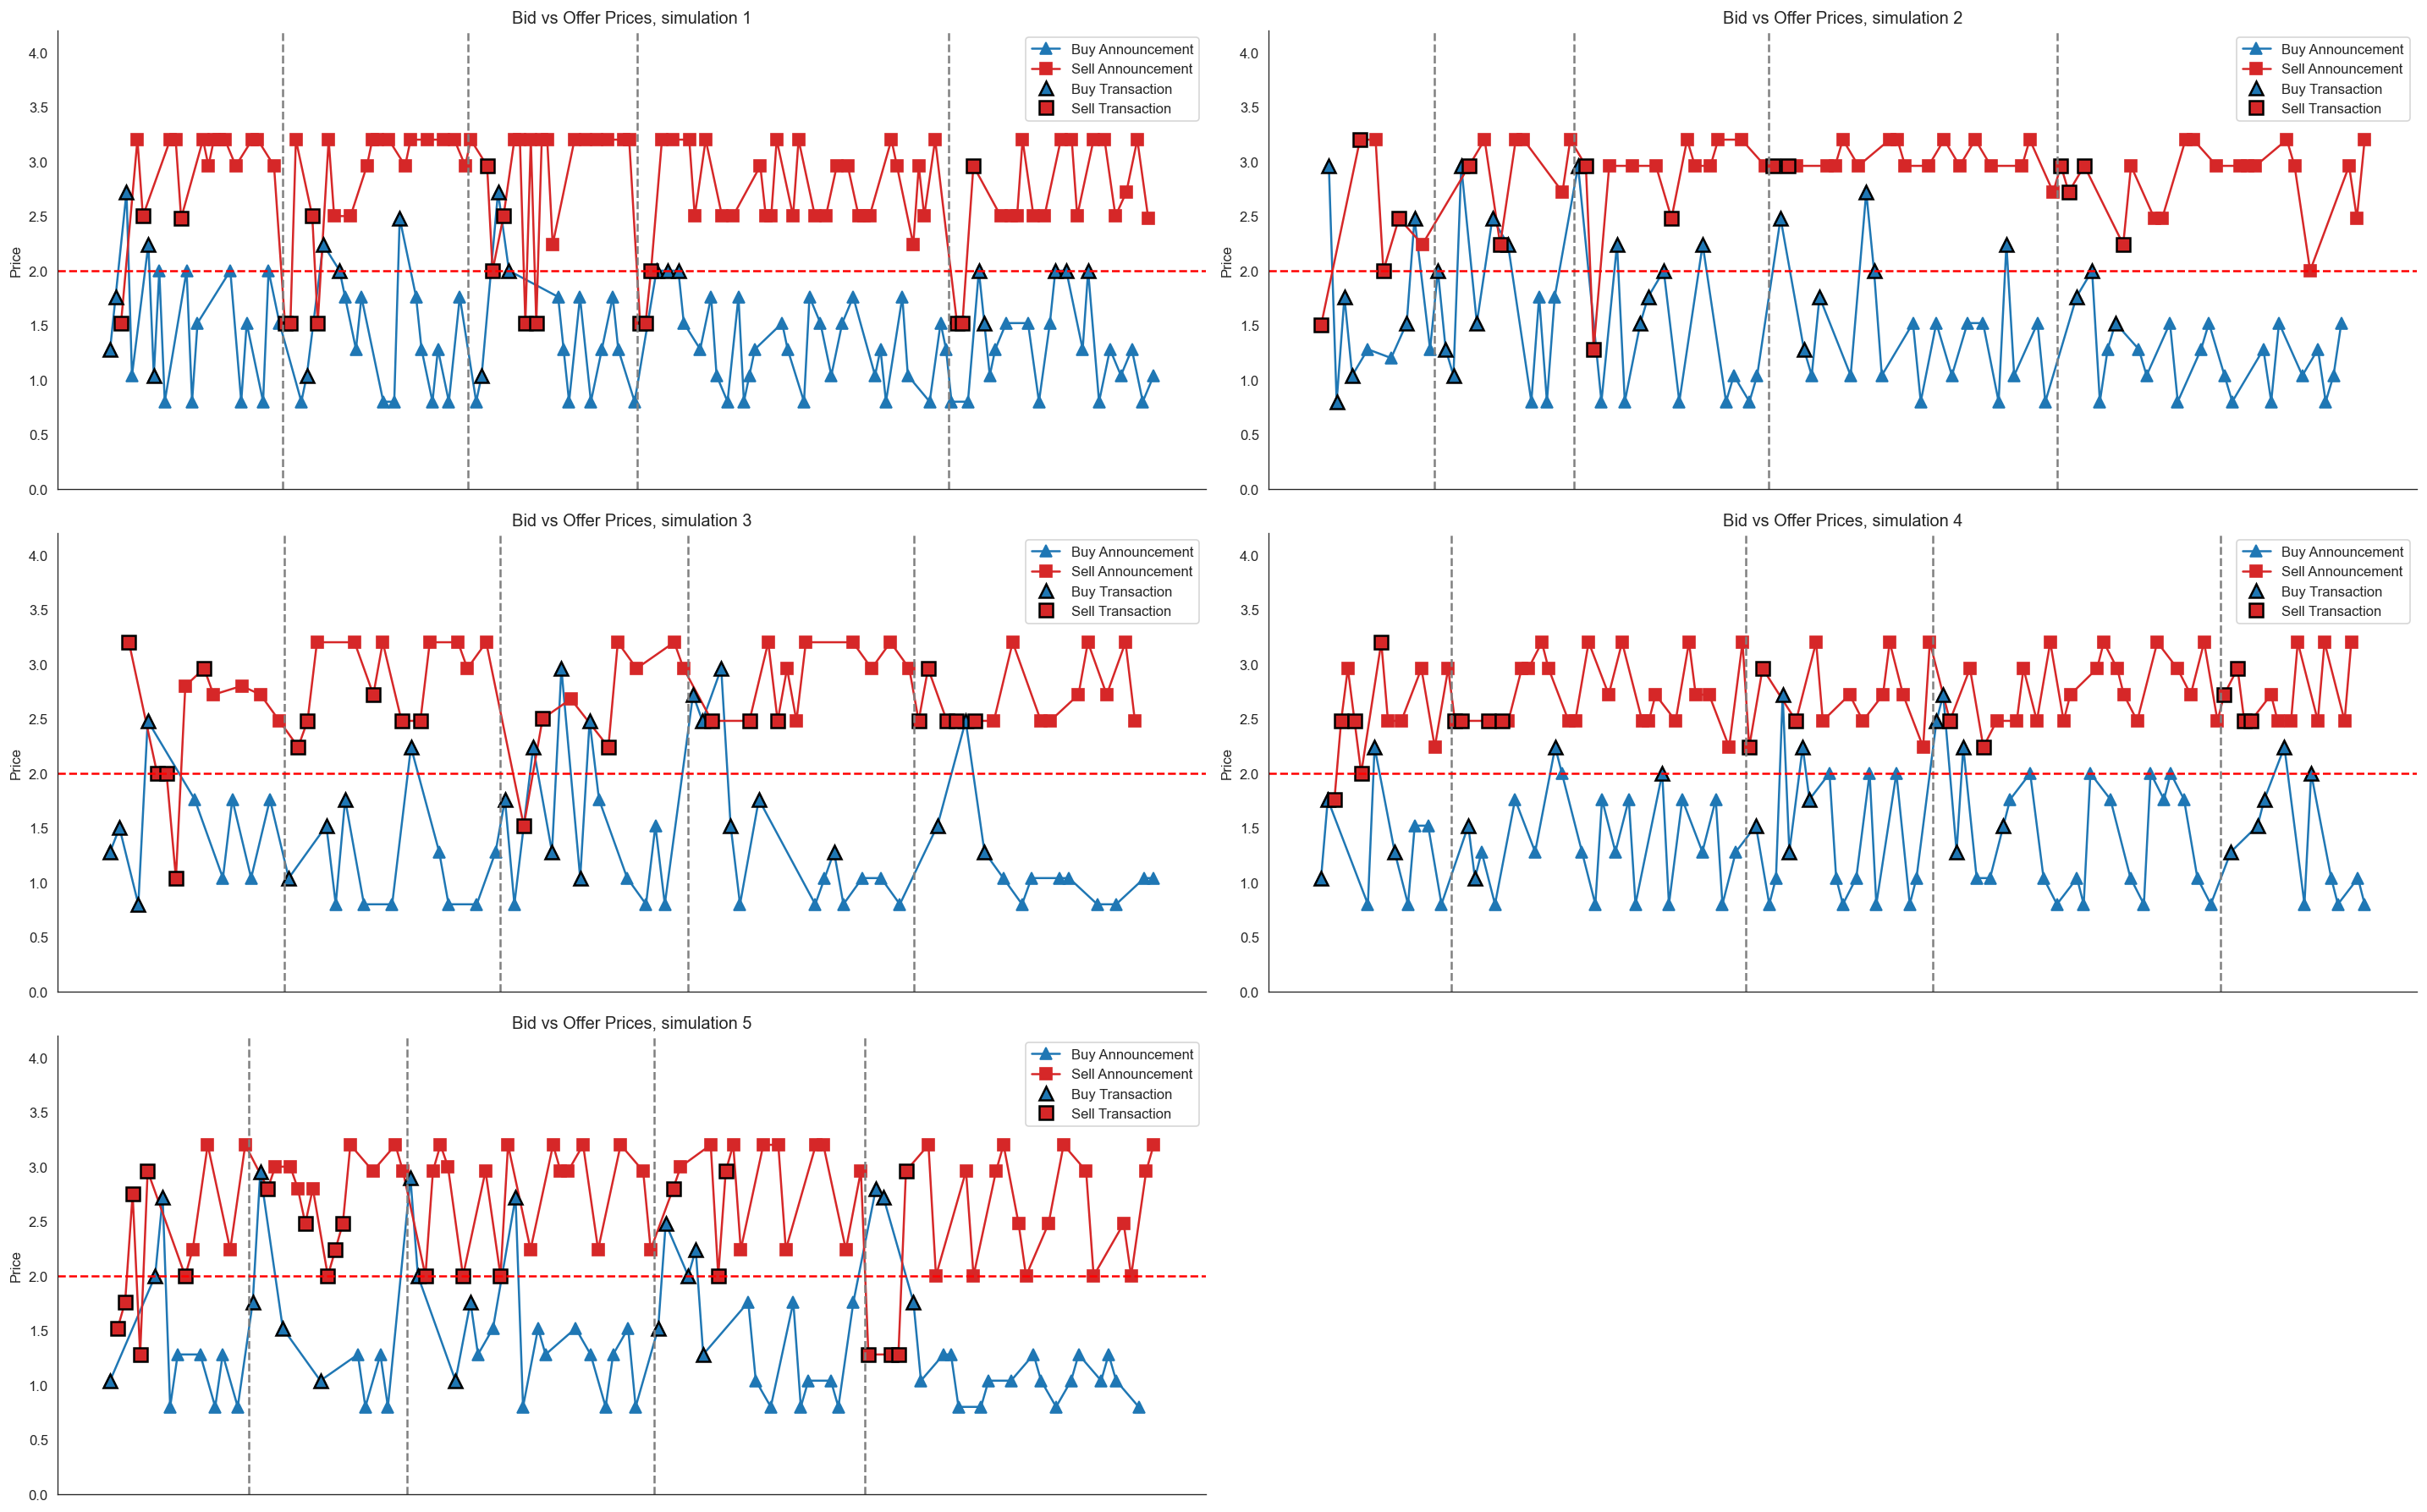

In [399]:
# Plot Announcement vs Transaction Prices for ALL simulations

sims = df_announcements['sim'].unique()
n_sims = len(sims)

# Layout: up to 2 columns
n_cols = 2
n_rows = (n_sims + n_cols - 1) // n_cols  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12 * n_cols, 5 * n_rows))
axes = axes.flatten()  # Makes indexing easier regardless of shape

# --- Dynamic axis limits ---
y_min = np.max([np.concat([supply, demand]).min() - 1, 0])
y_max = np.concat([supply, demand]).max() + 1

for i, sim in enumerate(sorted(sims)):
    ax = axes[i]

    df_plot = df_announcements[df_announcements['sim'] == sim]

    # Split data by buy/sell type (reindex masks to avoid alignment warning)
    df_buy  = df_plot[buy_mask.reindex(df_plot.index,  fill_value=False)]
    df_sell = df_plot[sell_mask.reindex(df_plot.index, fill_value=False)]

    # --- Plot ALL announcements by type WITH connecting lines ---
    ax.plot(df_buy.index,  df_buy['price'],
            marker='^', markersize=8, linestyle='-',
            label='Buy Announcement', color='#1f77b4')

    ax.plot(df_sell.index, df_sell['price'],
            marker='s', markersize=8, linestyle='-',
            label='Sell Announcement', color='#d62728')

    # --- Plot TRANSACTIONS by type ---
    df_buy_trans  = df_buy[df_buy['transaction_made']   == True]
    df_sell_trans = df_sell[df_sell['transaction_made'] == True]

    ax.plot(df_buy_trans.index, df_buy_trans['price'],
            marker='^', markersize=10, linestyle='',
            markeredgecolor='black', markeredgewidth=1.5,
            label='Buy Transaction', color='#1f77b4')

    ax.plot(df_sell_trans.index, df_sell_trans['price'],
            marker='s', markersize=10, linestyle='',
            markeredgecolor='black', markeredgewidth=1.5,
            label='Sell Transaction', color='#d62728')

    # --- Formatting ---
    last_indices_in_round = df_plot.groupby('round')['iteration'].apply(lambda g: g.index.max())
    for x in last_indices_in_round[:-1]:
        ax.axvline(x=x + 0.5, color='grey', linestyle='--', linewidth=1.5)

    ax.axhline(y=p_eq, color='red', linestyle='--')
    ax.set_xticks([])
    ax.set_title(f'Bid vs Offer Prices, simulation {sim}')
    ax.set_ylabel('Price')
    ax.set_ylim(y_min, y_max)
    ax.legend()

# Hide any unused subplots (if n_sims is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [400]:
# calculate standard deviaion of bid/sell announcements by simulation and round
df_buy_announcements = df_announcements.loc[df_announcements["announcement_type"]=="buy"]
df_sell_announcements = df_announcements.loc[df_announcements["announcement_type"]=="sell"]
df_buy_std = df_buy_announcements.groupby(["sim", "round"])["price"].std()
df_sell_std = df_sell_announcements.groupby(["sim", "round"])["price"].std()
df_std = pd.concat([df_buy_std, df_sell_std], axis=1)
df_std.columns = ["bid", "offer"]

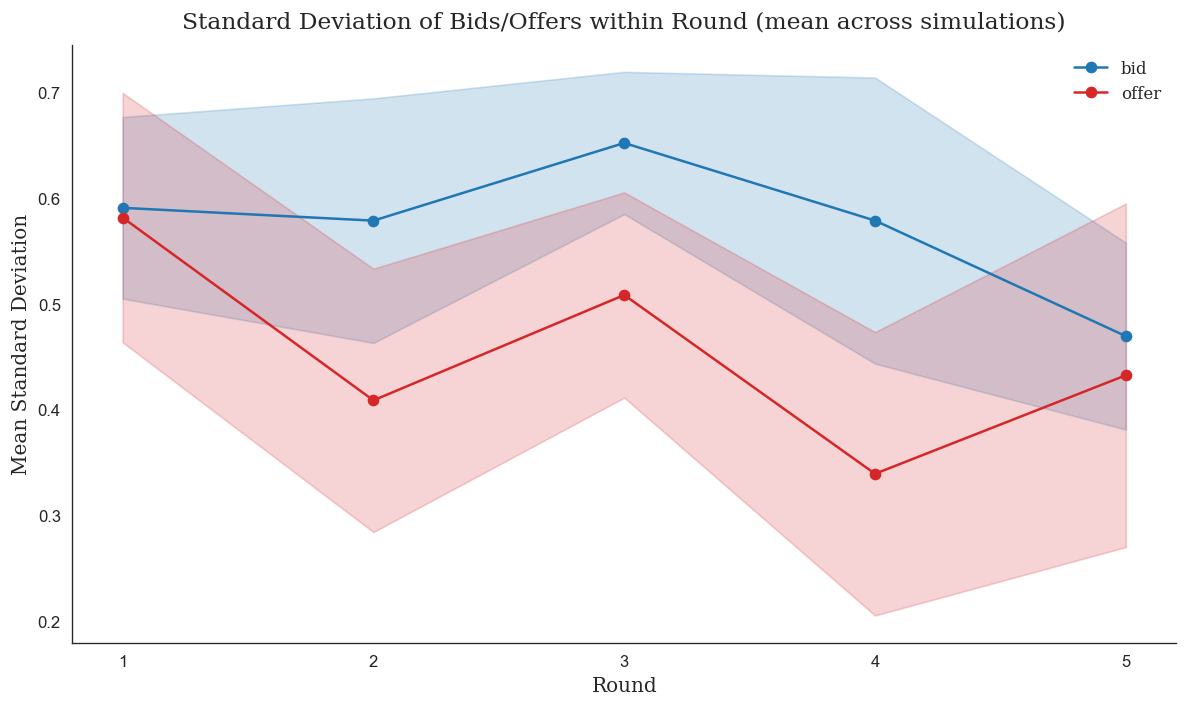

In [401]:
# plot the standard deviaion of bid/sell announcements by round (mean across simulations with cros-simulation STD bands around)
df = df_std.copy()
mean = df.groupby(level=1).mean()
std = df.groupby(level=1).std()

# construct the chart
colors = {'offer': '#d62728', 'bid': '#1f77b4'}
fig, ax = plt.subplots(figsize=(10, 6))
for col in df.columns:
    ax.plot(mean.index, mean[col], label=col, marker="o", color=colors[col])
    ax.fill_between(mean.index, mean[col] - std[col], mean[col] + std[col], alpha=0.2, color=colors[col])


# Chart Formatting
ax.set_xticks(mean.index)
ax.legend(loc='upper right', frameon=False, prop={'family': 'serif', 'size':10})
ax.set_xlabel("Round", fontsize=12, family='serif')
ax.set_ylabel("Mean Standard Deviation", fontsize=12, family='serif')
ax.set_title("Standard Deviation of Bids/Offers within Round (mean across simulations)",
             fontsize=14, family='serif', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plot
plt.tight_layout()
plt.show()

# Analyse Responses

## Acceptance rate vs reservation price

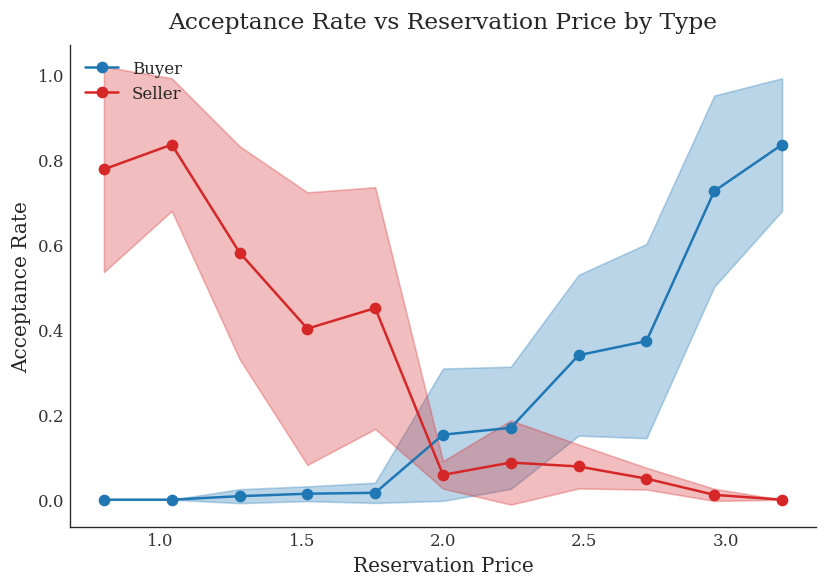

In [402]:
# Plot Acceptance Rate vs Reservation Price with 95% CIs
df = df_data_agents_all.loc[df_data_agents_all['action']=='respond']
df = df.groupby(['sim', 'agent_type', 'agent_id', 'reservation_price', 'outcome']).agg({
    'price': 'count'
}
).reset_index()
df = df.pivot(index=['sim', 'agent_type', 'agent_id', 'reservation_price'], 
                   columns='outcome',
                   values='price').fillna(0)
df['total'] = df['accepted'] + df['rejected']

df['acceptance_rate'] = df['accepted']/df['total']
df = df.reset_index()

# --- Aggregate over simulations ---
agg = df.groupby(['agent_type', 'reservation_price']).agg(
    mean_rate=('acceptance_rate', 'mean'),
    se=('acceptance_rate', lambda x: x.std(ddof=1)/np.sqrt(len(x)))
).reset_index()
agg['ci95'] = 1.96 * agg['se']

# --- Plot ---
sns.set_style("white")
fig, ax = plt.subplots(figsize=(7,5))

types = agg['agent_type'].unique()
colors = {'buyer': '#1f77b4', 'seller': '#d62728'}

for t in types:
    df_t = agg[agg['agent_type'] == t]
    ax.plot(df_t['reservation_price'], df_t['mean_rate'],
            marker='o', color=colors[t], label=t.capitalize())
    ax.fill_between(df_t['reservation_price'],
                    df_t['mean_rate'] - df_t['ci95'],
                    df_t['mean_rate'] + df_t['ci95'],
                    color=colors[t], alpha=0.3)

# Labels and title
ax.set_xlabel("Reservation Price", fontsize=12, family='serif')
ax.set_ylabel("Acceptance Rate", fontsize=12, family='serif')
ax.set_title("Acceptance Rate vs Reservation Price by Type",
             fontsize=14, family='serif', pad=10)

# Tick styling
ax.tick_params(axis='both', direction='in', labelsize=10, colors='#333333')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_family('serif')

# Spines and legend
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.legend(loc='upper left', frameon=False, prop={'family': 'serif', 'size':10})

ax.grid(False)
fig.tight_layout()
plt.show()


# Rent Seeking Analysis

In [403]:
# ============================================================
# CELL 0 — Preparation (multi-simulation)
# ============================================================
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# --- Assumes df_data_all and df_data_agents_all are already loaded -----------
# with a 'sim' column identifying each simulation run.

ih = df_data_all.copy()
ah = df_data_agents_all.copy()

# --- Deduplicated announcements (one row per unique announcement) -------------
ann = (
    ih[ih['announcement_made'] == True]
    .drop_duplicates(subset=['sim', 'round', 'iteration', 'announcing_agent_id', 'price', 'announcement_type'])
    .copy()
)
ann['side'] = ann['announcement_type'].map({'buy': 'buyer', 'sell': 'seller'})
ann['attempted_rent'] = np.where(
    ann['announcement_type'] == 'buy',
    ann['announcing_agent_reservation_price'] - ann['price'],
    ann['price'] - ann['announcing_agent_reservation_price'],
)

# --- Completed transactions (deduplicated) ------------------------------------
tx = (
    ih[ih['transaction_made'] == True]
    .drop_duplicates(subset=['sim', 'round', 'iteration', 'price'])
    .copy()
)
tx['buyer_rent'] = np.where(
    tx['announcement_type'] == 'buy',
    tx['announcing_agent_reservation_price'] - tx['price'],
    tx['responding_agent_reservation_price'] - tx['price'],
)
tx['seller_rent'] = np.where(
    tx['announcement_type'] == 'sell',
    tx['price'] - tx['announcing_agent_reservation_price'],
    tx['price'] - tx['responding_agent_reservation_price'],
)
tx['total_surplus'] = tx['buyer_rent'] + tx['seller_rent']
valid = (tx['buyer_rent'] >= 0) & (tx['seller_rent'] >= 0)
tx['buyer_share'] = np.where(~valid, np.nan,
                    np.where(tx['total_surplus'] > 0, tx['buyer_rent'] / tx['total_surplus'], 0.5))
tx['seller_share'] = np.where(~valid, np.nan,
                    np.where(tx['total_surplus'] > 0, tx['seller_rent'] / tx['total_surplus'], 0.5))


tx['buyer_id'] = np.where(
    tx['announcement_type'] == 'buy', tx['announcing_agent_id'], tx['responding_agent_id'])
tx['seller_id'] = np.where(
    tx['announcement_type'] == 'sell', tx['announcing_agent_id'], tx['responding_agent_id'])

n_sims_actual = ih['sim'].nunique()
print(f'Simulations: {n_sims_actual}  |  Unique announcements: {len(ann)}  |  Transactions: {len(tx)}')
print(f'Rounds: {sorted(ih["round"].unique())}')

# --- calculate the equilibrium ------------------------------------
demand = np.round(
    np.linspace(
        config["experiment"]["buyers"]["max"],
        config["experiment"]["buyers"]["min"],
        config["experiment"]["buyers"]["num"],
    ),
    2,
)
supply = np.round(
    np.linspace(
        config["experiment"]["sellers"]["min"],
        config["experiment"]["sellers"]["max"],
        config["experiment"]["sellers"]["num"],
    ),
    2,
)
q_eq, p_eq = find_equilibrium(supply=supply, demand=demand)
print(f"Equilibrium quantity: {q_eq}")
print(f"Equilibrium price: ${p_eq}")

# --- calculate the surplus in equilibrium ------------------------------------
buyer_surplus = np.sum(demand[:q_eq] - p_eq)
seller_surplus = np.sum(p_eq - supply[:q_eq])
total_surplus = buyer_surplus + seller_surplus

print(f'Buyer surplus:  ${buyer_surplus:.2f}')
print(f'Seller surplus: ${seller_surplus:.2f}')
print(f'Total surplus:  ${total_surplus:.2f}')

Simulations: 5  |  Unique announcements: 736  |  Transactions: 207
Rounds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Equilibrium quantity: 6
Equilibrium price: $2.0
Buyer surplus:  $3.60
Seller surplus: $3.60
Total surplus:  $7.20


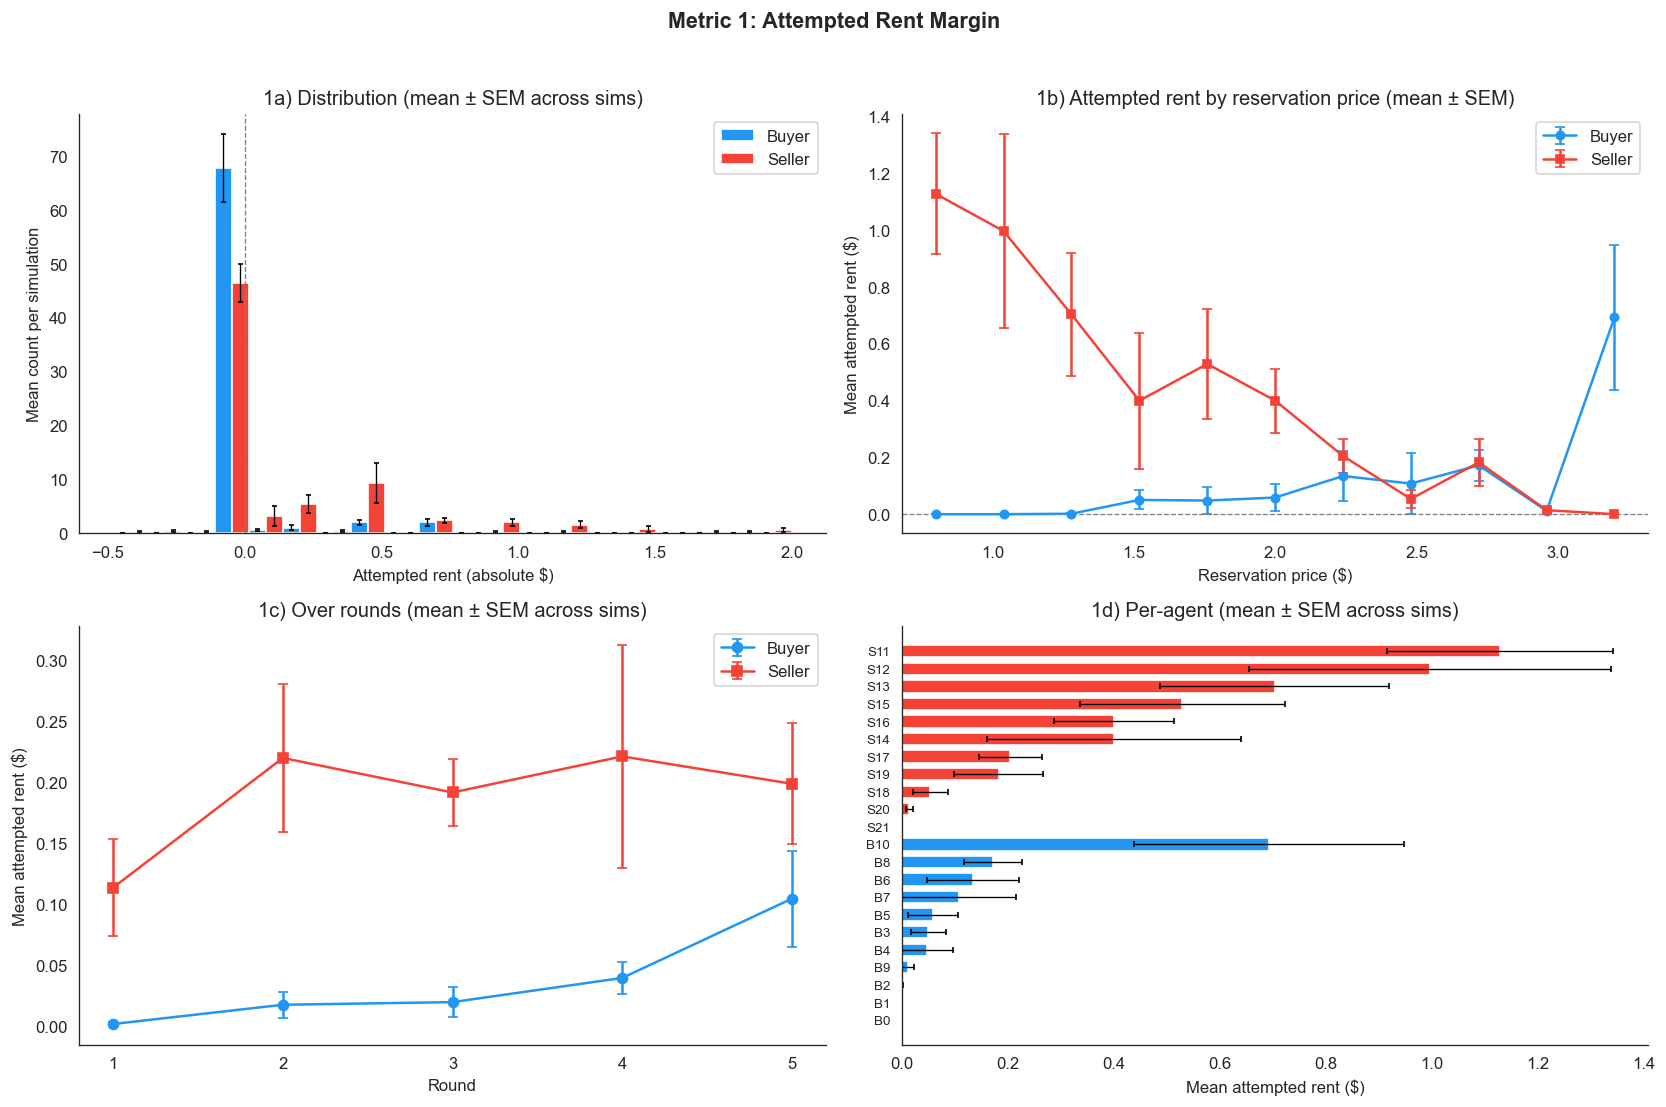

In [404]:
# ============================================================
# CELL 1 — Metric 1: Attempted Rent Margin (multi-sim)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 1a: Distribution with per-bin mean ± SEM across sims --------------------
ax = axes[0, 0]
all_vals = ann['attempted_rent'].dropna()
bin_edges = np.linspace(all_vals.min(), all_vals.max(), 21)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0])
half = width / 2
sims = sorted(ann['sim'].unique())

for side, color, offset in [('buyer', '#2196F3', -half/2), ('seller', '#F44336', half/2)]:
    counts = np.zeros((len(sims), len(bin_centers)))
    for i, s in enumerate(sims):
        vals = ann[(ann['side'] == side) & (ann['sim'] == s)]['attempted_rent']
        counts[i], _ = np.histogram(vals, bins=bin_edges)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(bin_centers + offset, mean_counts, width=half, color=color,
           edgecolor='white', label=side.title())
    ax.errorbar(bin_centers + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Attempted rent (absolute $)')
ax.set_ylabel('Mean count per simulation')
ax.set_title('1a) Distribution (mean ± SEM across sims)')
ax.legend()

# --- 1b: Attempted rent by reservation price (mean ± SEM across sims) --------
ax = axes[0, 1]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sub = ann[ann['side'] == side]
    sim_agent = (sub.groupby(['sim', 'announcing_agent_reservation_price'])['attempted_rent']
                 .mean().reset_index())
    agg = (sim_agent.groupby('announcing_agent_reservation_price')['attempted_rent']
           .agg(['mean', 'sem']).reset_index())
    ax.errorbar(agg['announcing_agent_reservation_price'], agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title(), markersize=5)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Reservation price ($)')
ax.set_ylabel('Mean attempted rent ($)')
ax.set_title('1b) Attempted rent by reservation price (mean ± SEM)')
ax.legend()

# --- 1c: Mean attempted rent by round (averaged across sims) ------------------
ax = axes[1, 0]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sim_round = (ann[ann['side'] == side]
                 .groupby(['sim', 'round'])['attempted_rent']
                 .mean()
                 .reset_index())
    agg = sim_round.groupby('round')['attempted_rent'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.set_xlabel('Round')
ax.set_ylabel('Mean attempted rent ($)')
ax.set_title('1c) Over rounds (mean ± SEM across sims)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.legend()

# --- 1d: Per-agent mean attempted rent (mean ± SEM across sims) ---------------
ax = axes[1, 1]
agent_sim_rent = (ann.groupby(['announcing_agent_id', 'side', 'sim'])['attempted_rent']
                  .mean().reset_index())
agent_rent = (agent_sim_rent.groupby(['announcing_agent_id', 'side'])['attempted_rent']
              .agg(['mean', 'sem']).reset_index())

buyers = agent_rent[agent_rent['side'] == 'buyer'].sort_values('mean')
sellers = agent_rent[agent_rent['side'] == 'seller'].sort_values('mean')
y_pos = np.arange(len(buyers) + len(sellers))
labels, means, sems, colors = [], [], [], []
for _, r in buyers.iterrows():
    labels.append(f'B{int(r.announcing_agent_id)}')
    means.append(r['mean'])
    sems.append(r['sem'])
    colors.append('#2196F3')
for _, r in sellers.iterrows():
    labels.append(f'S{int(r.announcing_agent_id)}')
    means.append(r['mean'])
    sems.append(r['sem'])
    colors.append('#F44336')

ax.barh(y_pos, means, xerr=sems, color=colors, edgecolor='white', height=0.7,
        capsize=2, error_kw={'lw': 0.8})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Mean attempted rent ($)')
ax.set_title('1d) Per-agent (mean ± SEM across sims)')

fig.suptitle('Metric 1: Attempted Rent Margin', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

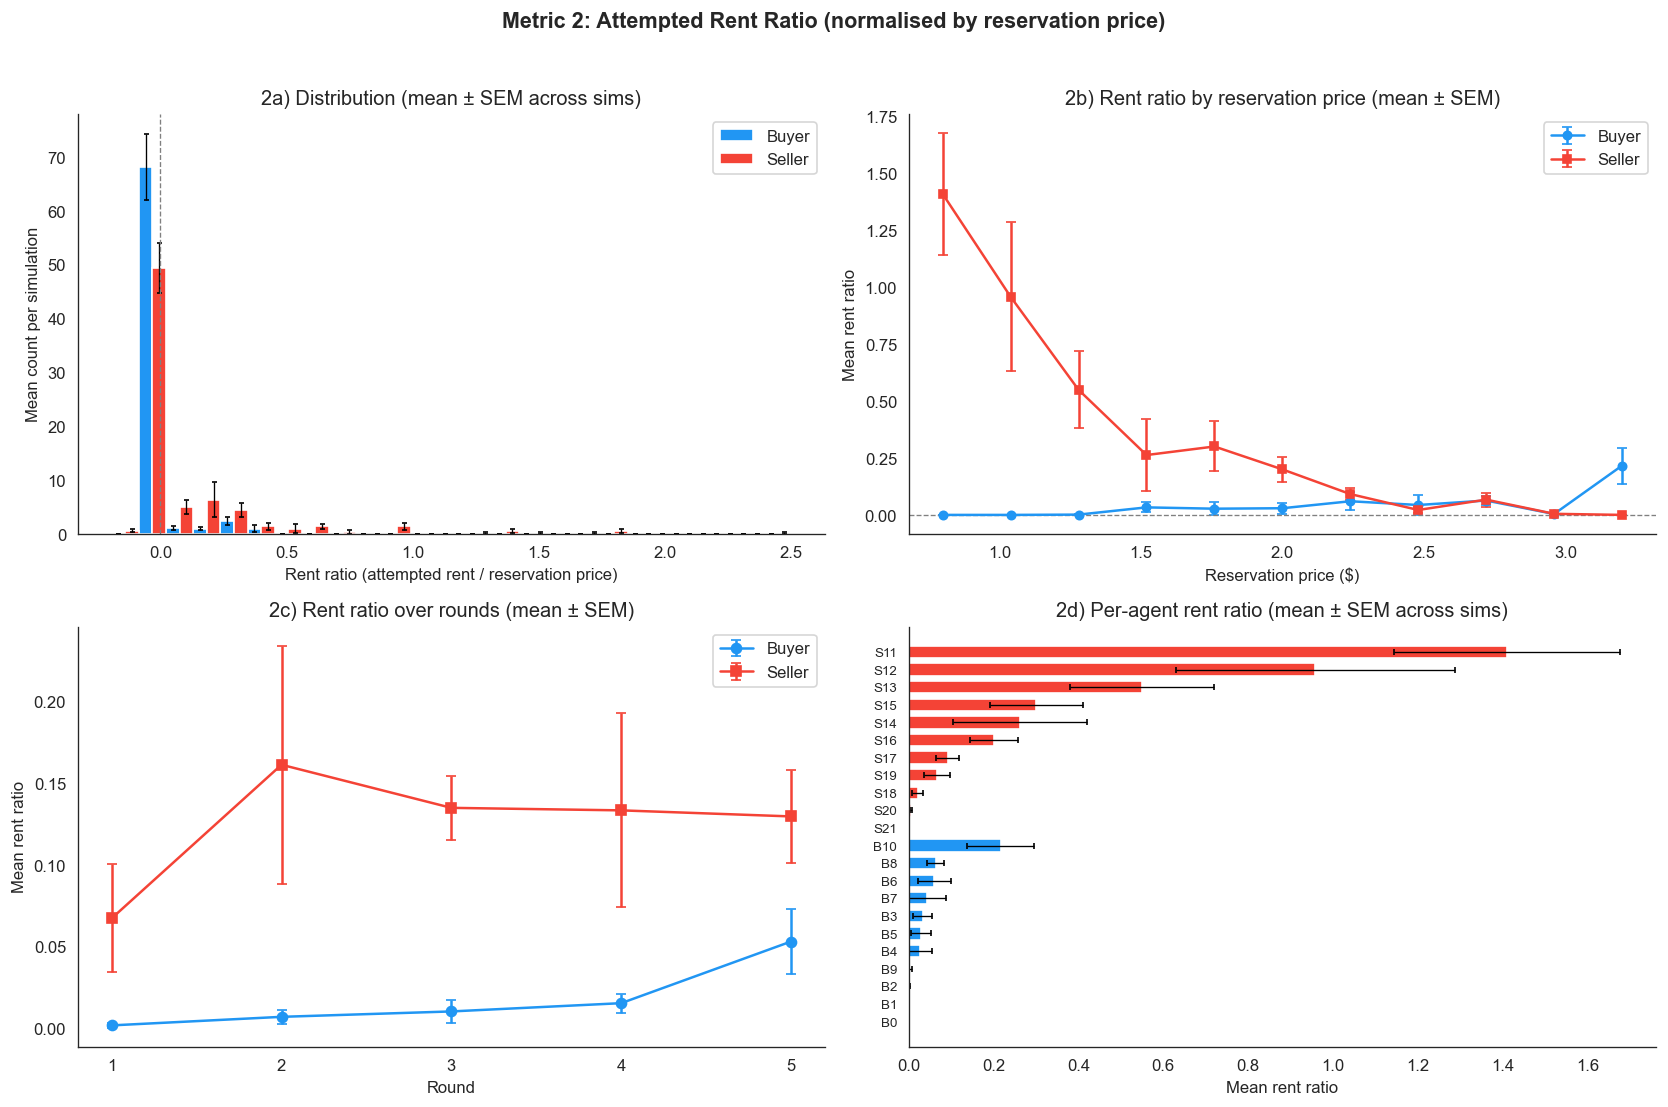

In [405]:
# ============================================================
# CELL 2 — Metric 2: Attempted Rent Ratio (multi-sim)
# ============================================================

ann['rent_ratio'] = ann['attempted_rent'] / ann['announcing_agent_reservation_price']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 2a: Distribution (mean ± SEM per bin across sims) -----------------------
ax = axes[0, 0]
all_ratios = ann['rent_ratio'].dropna()
bin_edges = np.linspace(all_ratios.min(), all_ratios.max(), 26)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0])
half = width / 2
sims = sorted(ann['sim'].unique())

for side, color, offset in [('buyer', '#2196F3', -half/2), ('seller', '#F44336', half/2)]:
    counts = np.zeros((len(sims), len(bin_centers)))
    for i, s in enumerate(sims):
        vals = ann[(ann['side'] == side) & (ann['sim'] == s)]['rent_ratio']
        counts[i], _ = np.histogram(vals, bins=bin_edges)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(bin_centers + offset, mean_counts, width=half, color=color,
           edgecolor='white', label=side.title())
    ax.errorbar(bin_centers + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Rent ratio (attempted rent / reservation price)')
ax.set_ylabel('Mean count per simulation')
ax.set_title('2a) Distribution (mean ± SEM across sims)')
ax.legend()

# --- 2b: Rent ratio by reservation price (mean ± SEM across sims) ------------
ax = axes[0, 1]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sub = ann[ann['side'] == side]
    sim_agent = (sub.groupby(['sim', 'announcing_agent_reservation_price'])['rent_ratio']
                 .mean().reset_index())
    agg = (sim_agent.groupby('announcing_agent_reservation_price')['rent_ratio']
           .agg(['mean', 'sem']).reset_index())
    ax.errorbar(agg['announcing_agent_reservation_price'], agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title(), markersize=5)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Reservation price ($)')
ax.set_ylabel('Mean rent ratio')
ax.set_title('2b) Rent ratio by reservation price (mean ± SEM)')
ax.legend()

# --- 2c: Mean rent ratio by round (mean ± SEM across sims) --------------------
ax = axes[1, 0]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sr = (ann[ann['side'] == side]
          .groupby(['sim', 'round'])['rent_ratio']
          .mean()
          .reset_index())
    agg = sr.groupby('round')['rent_ratio'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.set_xlabel('Round')
ax.set_ylabel('Mean rent ratio')
ax.set_title('2c) Rent ratio over rounds (mean ± SEM)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.legend()

# --- 2d: Per-agent mean rent ratio (mean ± SEM across sims) ------------------
ax = axes[1, 1]
agent_sim_ratio = (ann.groupby(['announcing_agent_id', 'side', 'sim'])['rent_ratio']
                   .mean().reset_index())
agent_ratio = (agent_sim_ratio.groupby(['announcing_agent_id', 'side'])['rent_ratio']
               .agg(['mean', 'sem']).reset_index())

buyers = agent_ratio[agent_ratio['side'] == 'buyer'].sort_values('mean')
sellers = agent_ratio[agent_ratio['side'] == 'seller'].sort_values('mean')
y_pos = np.arange(len(buyers) + len(sellers))
labels, means, sems, colors = [], [], [], []
for _, r in buyers.iterrows():
    labels.append(f'B{int(r.announcing_agent_id)}')
    means.append(r['mean'])
    sems.append(r['sem'])
    colors.append('#2196F3')
for _, r in sellers.iterrows():
    labels.append(f'S{int(r.announcing_agent_id)}')
    means.append(r['mean'])
    sems.append(r['sem'])
    colors.append('#F44336')

ax.barh(y_pos, means, xerr=sems, color=colors, edgecolor='white', height=0.7,
        capsize=2, error_kw={'lw': 0.8})
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Mean rent ratio')
ax.set_title('2d) Per-agent rent ratio (mean ± SEM across sims)')

fig.suptitle('Metric 2: Attempted Rent Ratio (normalised by reservation price)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

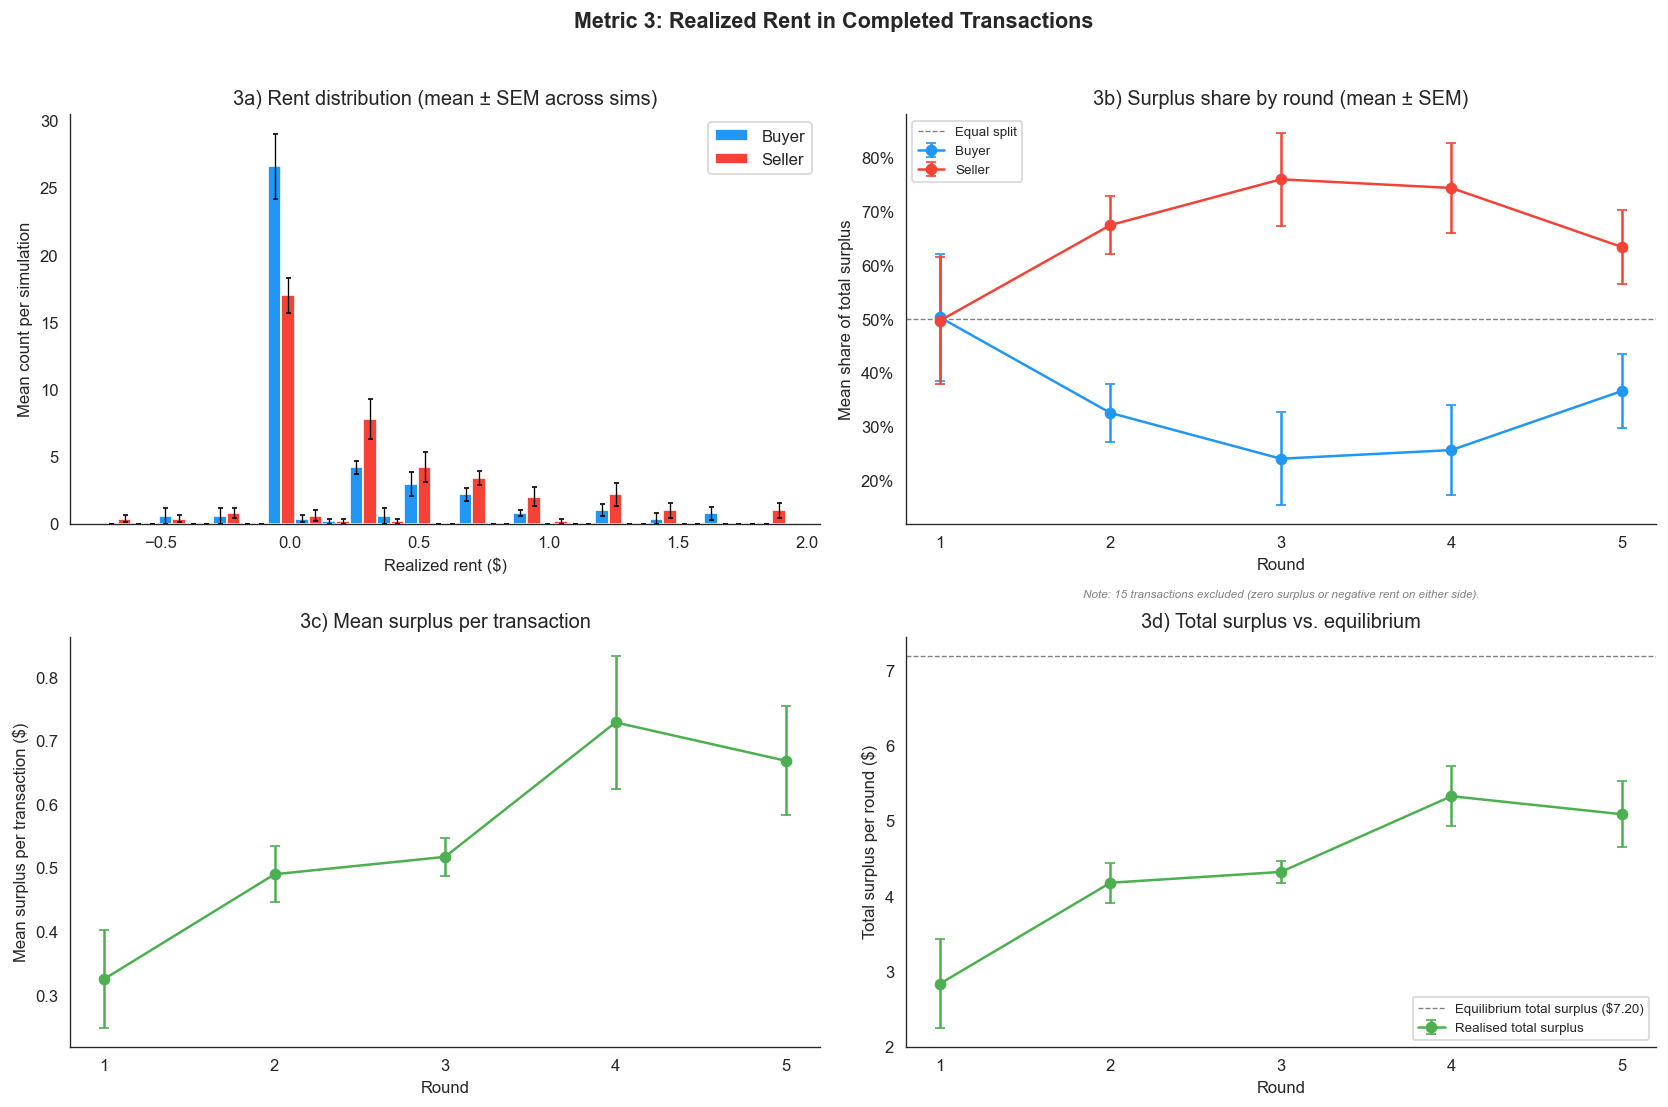

In [406]:
# ============================================================
# CELL 3 — Metric 3: Realized Rent (multi-sim)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 3a: Distribution of realized rent (mean ± SEM per bin across sims) -------
ax = axes[0, 0]
all_rents = pd.concat([tx['buyer_rent'], tx['seller_rent']])
bin_edges = np.linspace(all_rents.min(), all_rents.max(), 26)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0])
half = width / 2
sims = sorted(tx['sim'].unique())

for col, color, offset, label in [('buyer_rent', '#2196F3', -half/2, 'Buyer'),
                                    ('seller_rent', '#F44336', half/2, 'Seller')]:
    counts = np.zeros((len(sims), len(bin_centers)))
    for i, s in enumerate(sims):
        counts[i], _ = np.histogram(tx[tx['sim'] == s][col], bins=bin_edges)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(bin_centers + offset, mean_counts, width=half, color=color,
           edgecolor='white', label=label)
    ax.errorbar(bin_centers + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)
ax.set_xlabel('Realized rent ($)')
ax.set_ylabel('Mean count per simulation')
ax.set_title('3a) Rent distribution (mean ± SEM across sims)')
ax.legend()

# --- 3b: Surplus share by round (mean ± SEM across sims) ---------------------
ax = axes[0, 1]
tx_pos = tx[tx['total_surplus'] > 0].copy()
n_excluded = tx['buyer_share'].isna().sum()
sim_round_shares = (tx_pos.groupby(['sim', 'round'])[['buyer_share', 'seller_share']]
                    .mean().reset_index())
for col, color, label in [('buyer_share', '#2196F3', 'Buyer'), ('seller_share', '#F44336', 'Seller')]:
    agg = sim_round_shares.groupby('round')[col].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt='-o', color=color, capsize=3, label=label)
ax.axhline(0.5, color='grey', ls='--', lw=0.8, label='Equal split')
ax.set_ylabel('Mean share of total surplus')
ax.set_xlabel('Round')
ax.set_title('3b) Surplus share by round (mean ± SEM)')
ax.set_xticks(sorted(tx['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.text(0.5, -0.18, f'Note: {n_excluded} transactions excluded (zero surplus or negative rent on either side).',
        transform=ax.transAxes, fontsize=7, ha='center', style='italic', color='grey')

# --- 3c: Mean total surplus per transaction by round --------------------------
ax = axes[1, 0]
sim_round_mean = tx.groupby(['sim', 'round'])['total_surplus'].mean().reset_index()
agg = sim_round_mean.groupby('round')['total_surplus'].agg(['mean', 'sem'])
ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
            fmt='-o', color='#4CAF50', capsize=3)
ax.set_xlabel('Round')
ax.set_ylabel('Mean surplus per transaction ($)')
ax.set_title('3c) Mean surplus per transaction')
ax.set_xticks(sorted(tx['round'].unique()))

# --- 3d: Total surplus per round vs equilibrium ------------------------------
ax = axes[1, 1]
sim_round_sum = tx.groupby(['sim', 'round'])['total_surplus'].sum().reset_index()
agg = sim_round_sum.groupby('round')['total_surplus'].agg(['mean', 'sem'])
ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
            fmt='-o', color='#4CAF50', capsize=3, label='Realised total surplus')
ax.axhline(total_surplus, color='grey', ls='--', lw=0.8, label=f'Equilibrium total surplus (${total_surplus:.2f})')
ax.set_xlabel('Round')
ax.set_ylabel('Total surplus per round ($)')
ax.set_title('3d) Total surplus vs. equilibrium')
ax.set_xticks(sorted(tx['round'].unique()))
ax.legend(fontsize=8)

fig.suptitle('Metric 3: Realized Rent in Completed Transactions',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

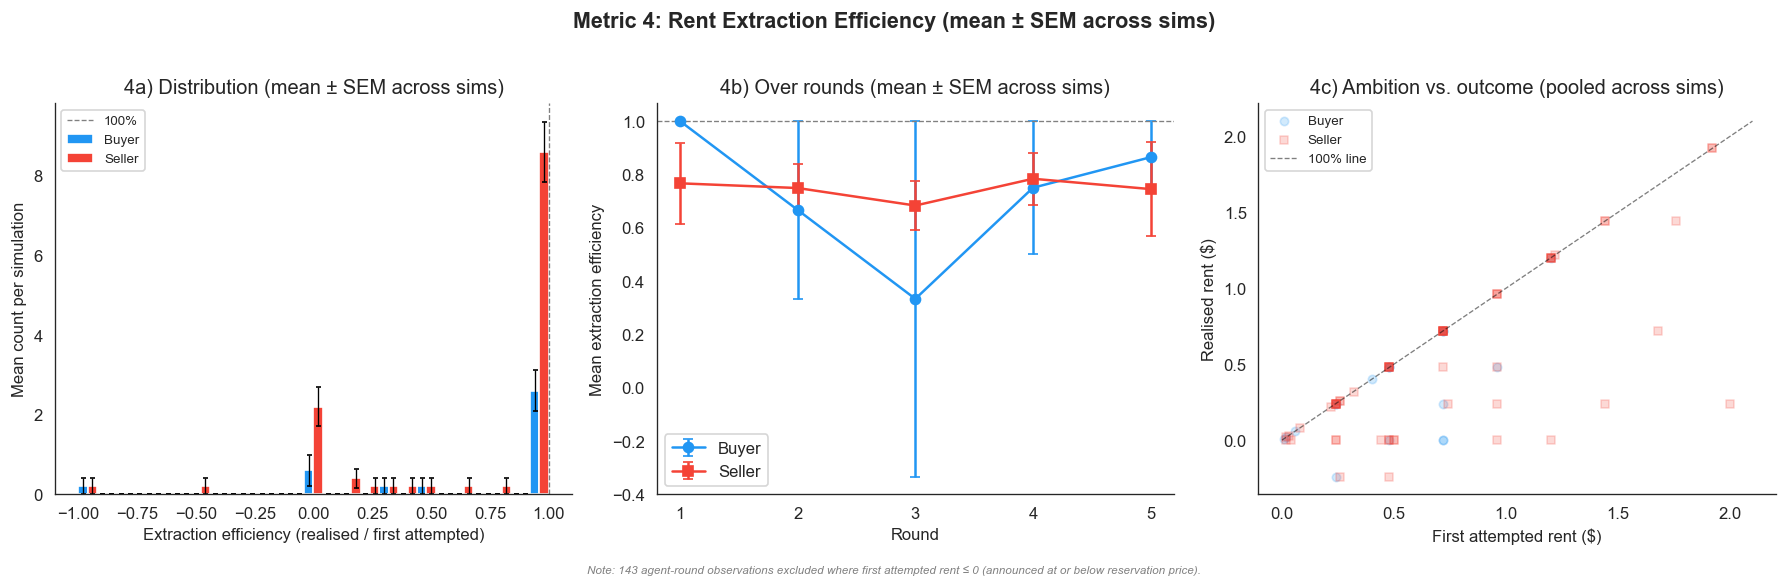


--- Efficiency summary by side ---
        count   mean    std    min    25%  50%  75%  max
side                                                    
buyer    19.0  0.675  0.562 -1.000  0.417  1.0  1.0  1.0
seller   64.0  0.701  0.479 -0.923  0.306  1.0  1.0  1.0


In [407]:
# ============================================================
# CELL 4 — Metric 4: Rent Extraction Efficiency (multi-sim)
#   Compares each agent's FIRST announcement in a round with
#   the rent they EVENTUALLY realised — as announcer or responder.
# ============================================================

# --- Step 1: First announcement per (sim, agent, round) ----------------------
ann_first = (
    ann.sort_values('iteration')
    .groupby(['sim', 'announcing_agent_id', 'round'])
    .first()
    .reset_index()
)
ann_first = ann_first.rename(columns={'attempted_rent': 'first_attempted_rent', 'price': 'first_price'})

# --- Step 2: Realised rent per (sim, agent, round) ---------------------------
records = []
for _, row in tx.iterrows():
    s, rnd, p = row['sim'], row['round'], row['price']
    if row['announcement_type'] == 'sell':
        records.append({'sim': s, 'agent_id': row['announcing_agent_id'], 'round': rnd,
                        'realized_rent': p - row['announcing_agent_reservation_price']})
        records.append({'sim': s, 'agent_id': row['responding_agent_id'], 'round': rnd,
                        'realized_rent': row['responding_agent_reservation_price'] - p})
    else:
        records.append({'sim': s, 'agent_id': row['announcing_agent_id'], 'round': rnd,
                        'realized_rent': row['announcing_agent_reservation_price'] - p})
        records.append({'sim': s, 'agent_id': row['responding_agent_id'], 'round': rnd,
                        'realized_rent': p - row['responding_agent_reservation_price']})
realized = pd.DataFrame(records)

# --- Step 3: Merge and compute efficiency ------------------------------------
eff = ann_first.merge(
    realized,
    left_on=['sim', 'announcing_agent_id', 'round'],
    right_on=['sim', 'agent_id', 'round'],
    how='inner',
)
eff = eff[eff['first_attempted_rent'] > 0].copy()
eff['side'] = eff['announcement_type'].map({'buy': 'buyer', 'sell': 'seller'})
eff['efficiency'] = eff['realized_rent'] / eff['first_attempted_rent']

# --- Plots -------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 4a: Distribution (mean ± SEM per bin across sims)
ax = axes[0]
all_eff = eff['efficiency'].dropna()
bin_edges = np.linspace(all_eff.min(), all_eff.max(), 26)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0])
half = width / 2
sims = sorted(eff['sim'].unique())

for side, color, offset in [('buyer', '#2196F3', -half/2), ('seller', '#F44336', half/2)]:
    counts = np.zeros((len(sims), len(bin_centers)))
    for i, s in enumerate(sims):
        vals = eff[(eff['side'] == side) & (eff['sim'] == s)]['efficiency']
        counts[i], _ = np.histogram(vals, bins=bin_edges)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(bin_centers + offset, mean_counts, width=half, color=color,
           edgecolor='white', label=side.title())
    ax.errorbar(bin_centers + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)
ax.axvline(1.0, color='grey', ls='--', lw=0.8, label='100%')
ax.set_xlabel('Extraction efficiency (realised / first attempted)')
ax.set_ylabel('Mean count per simulation')
ax.set_title('4a) Distribution (mean ± SEM across sims)')
ax.legend(fontsize=8)

# 4b: Efficiency by round (mean ± SEM across sims)
ax = axes[1]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sim_round = (eff[eff['side'] == side]
                 .groupby(['sim', 'round'])['efficiency']
                 .mean().reset_index())
    agg = sim_round.groupby('round')['efficiency'].agg(['mean', 'sem'])
    if len(agg) > 0:
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Round')
ax.set_ylabel('Mean extraction efficiency')
ax.set_title('4b) Over rounds (mean ± SEM across sims)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.legend()

# 4c: Scatter — ambition vs outcome (pooled)
ax = axes[2]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sub = eff[eff['side'] == side]
    ax.scatter(sub['first_attempted_rent'], sub['realized_rent'],
               alpha=0.2, c=color, marker=marker, s=25, label=side.title())
max_val = max(eff['first_attempted_rent'].max(), eff['realized_rent'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', lw=0.8, alpha=0.5, label='100% line')
ax.set_xlabel('First attempted rent ($)')
ax.set_ylabel('Realised rent ($)')
ax.set_title('4c) Ambition vs. outcome (pooled across sims)')
ax.legend(fontsize=8)

fig.suptitle('Metric 4: Rent Extraction Efficiency (mean ± SEM across sims)',
             fontsize=13, fontweight='bold', y=1.02)
n_excluded = len(ann_first.merge(realized, left_on=['sim','announcing_agent_id','round'],
    right_on=['sim','agent_id','round'], how='inner')) - len(eff)
fig.text(0.5, -0.02,
         f'Note: {n_excluded} agent-round observations excluded where first attempted rent ≤ 0 (announced at or below reservation price).',
         ha='center', fontsize=7, style='italic', color='grey')
plt.tight_layout()
plt.show()

print('\n--- Efficiency summary by side ---')
print(eff.groupby('side')['efficiency'].describe().round(3).to_string())

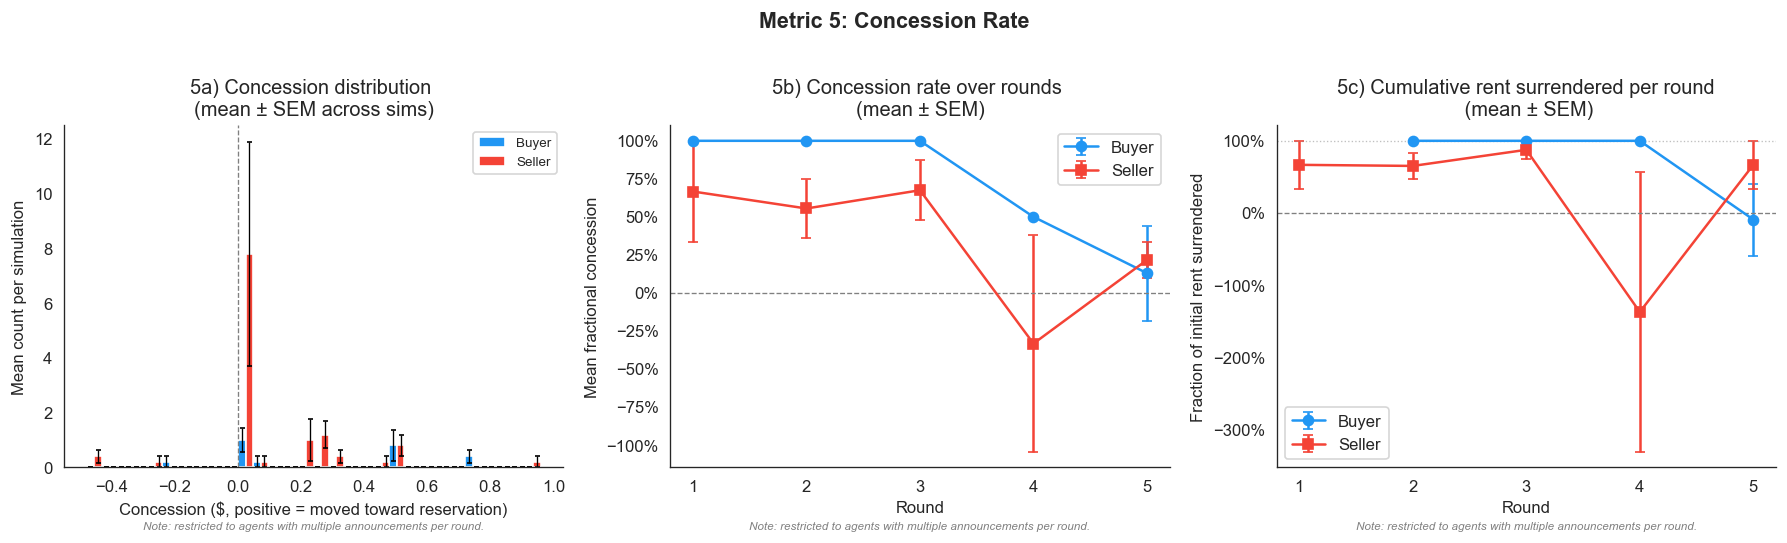


--- Step-level concession summary by side ---
       concession                                            frac_concession                                        
            count   mean    std   min  25%   50%   75%   max           count   mean    std   min  25%  50%  75%  max
side                                                                                                                
buyer        13.0  0.246  0.321 -0.24  0.0  0.08  0.48  0.72            13.0  0.397  0.622  -1.0  0.0  0.5  1.0  1.0
seller       62.0  0.091  0.217 -0.48  0.0  0.00  0.24  0.96            62.0 -0.039  3.005 -23.0  0.0  0.0  1.0  1.0

--- Cumulative rent surrendered per round by side ---
       rent_surrendered                                              frac_surrendered                                            
                  count   mean    std   min   25%   50%    75%   max            count   mean    std   min    25%    50%  75%  max
side                                                 

In [408]:
# ============================================================
# CELL 5 — Metric 7: Concession Rate (multi-sim)
# ============================================================

ann_sorted = ann.sort_values(['sim', 'announcing_agent_id', 'round', 'iteration']).copy()

concessions = []
for (sim, agent, rnd), grp in ann_sorted.groupby(['sim', 'announcing_agent_id', 'round']):
    if len(grp) < 2:
        continue
    grp = grp.sort_values('iteration')
    rents = grp['attempted_rent'].values
    iters = grp['iteration'].values
    side = grp['side'].iloc[0]
    for j in range(1, len(rents)):
        concession = rents[j - 1] - rents[j]
        remaining = rents[j - 1]
        if remaining <= 0:
            continue
        frac_concession = concession / remaining if remaining > 0 else np.nan
        concessions.append({
            'sim': sim, 'agent_id': agent, 'side': side, 'round': rnd,
            'from_iter': iters[j - 1], 'to_iter': iters[j],
            'concession': concession, 'frac_concession': frac_concession,
        })
conc = pd.DataFrame(concessions)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 5a: Distribution of concessions (mean ± SEM per bin across sims)
ax = axes[0]
all_conc = conc['concession'].dropna()
bin_edges = np.linspace(all_conc.min(), all_conc.max(), 31)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = (bin_edges[1] - bin_edges[0])
half = width / 2
sims = sorted(conc['sim'].unique())

for side, color, offset in [('buyer', '#2196F3', -half/2), ('seller', '#F44336', half/2)]:
    counts = np.zeros((len(sims), len(bin_centers)))
    for i, s in enumerate(sims):
        vals = conc[(conc['side'] == side) & (conc['sim'] == s)]['concession']
        counts[i], _ = np.histogram(vals, bins=bin_edges)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(bin_centers + offset, mean_counts, width=half, color=color,
           edgecolor='white', label=side.title())
    ax.errorbar(bin_centers + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Concession ($, positive = moved toward reservation)')
ax.set_ylabel('Mean count per simulation')
ax.set_title('5a) Concession distribution \n(mean ± SEM across sims)')
ax.legend(fontsize=8)
ax.text(0.5, -0.18, 'Note: restricted to agents with multiple announcements per round.',
        transform=ax.transAxes, fontsize=7, ha='center', style='italic', color='grey')

# 5b: Mean fractional concession by round (mean ± SEM across sims)
ax = axes[1]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sim_round = (conc[conc['side'] == side]
                 .groupby(['sim', 'round'])['frac_concession']
                 .mean().reset_index())
    agg = sim_round.groupby('round')['frac_concession'].agg(['mean', 'sem'])
    if len(agg) > 0:
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Round')
ax.set_ylabel('Mean fractional concession')
ax.set_title('5b) Concession rate over rounds \n(mean ± SEM)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.text(0.5, -0.18, 'Note: restricted to agents with multiple announcements per round.',
        transform=ax.transAxes, fontsize=7, ha='center', style='italic', color='grey')

# 5c: Total rent surrendered within a round (mean ± SEM across sims)
ax = axes[2]
ann_by_round = ann.sort_values('iteration').groupby(['sim', 'announcing_agent_id', 'round', 'side']).agg(
    first_rent=('attempted_rent', 'first'),
    last_rent=('attempted_rent', 'last'),
    n_announcements=('attempted_rent', 'count'),
).reset_index()
ann_by_round = ann_by_round[(ann_by_round['first_rent'] > 0) & (ann_by_round['n_announcements'] > 1)].copy()
ann_by_round['rent_surrendered'] = ann_by_round['first_rent'] - ann_by_round['last_rent']
ann_by_round['frac_surrendered'] = ann_by_round['rent_surrendered'] / ann_by_round['first_rent']

for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sim_round = (ann_by_round[ann_by_round['side'] == side]
                 .groupby(['sim', 'round'])['frac_surrendered']
                 .mean().reset_index())
    agg = sim_round.groupby('round')['frac_surrendered'].agg(['mean', 'sem'])
    if len(agg) > 0:
        ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                    fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.axhline(1, color='grey', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('Round')
ax.set_ylabel('Fraction of initial rent surrendered')
ax.set_title('5c) Cumulative rent surrendered per round\n (mean ± SEM)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.text(0.5, -0.18, 'Note: restricted to agents with multiple announcements per round.',
        transform=ax.transAxes, fontsize=7, ha='center', style='italic', color='grey')

fig.suptitle('Metric 5: Concession Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n--- Step-level concession summary by side ---')
print(conc.groupby('side')[['concession', 'frac_concession']].describe().round(3).to_string())

print('\n--- Cumulative rent surrendered per round by side ---')
cumul_summary = (ann_by_round.groupby('side')[['rent_surrendered', 'frac_surrendered']]
                 .describe().round(3))
print(cumul_summary.to_string())

print('\n--- Mean cumulative fraction surrendered by round and side ---')
cumul_by_round = (ann_by_round.groupby(['side', 'round'])['frac_surrendered']
                  .agg(['mean', 'std', 'count']).round(3))
print(cumul_by_round.to_string())

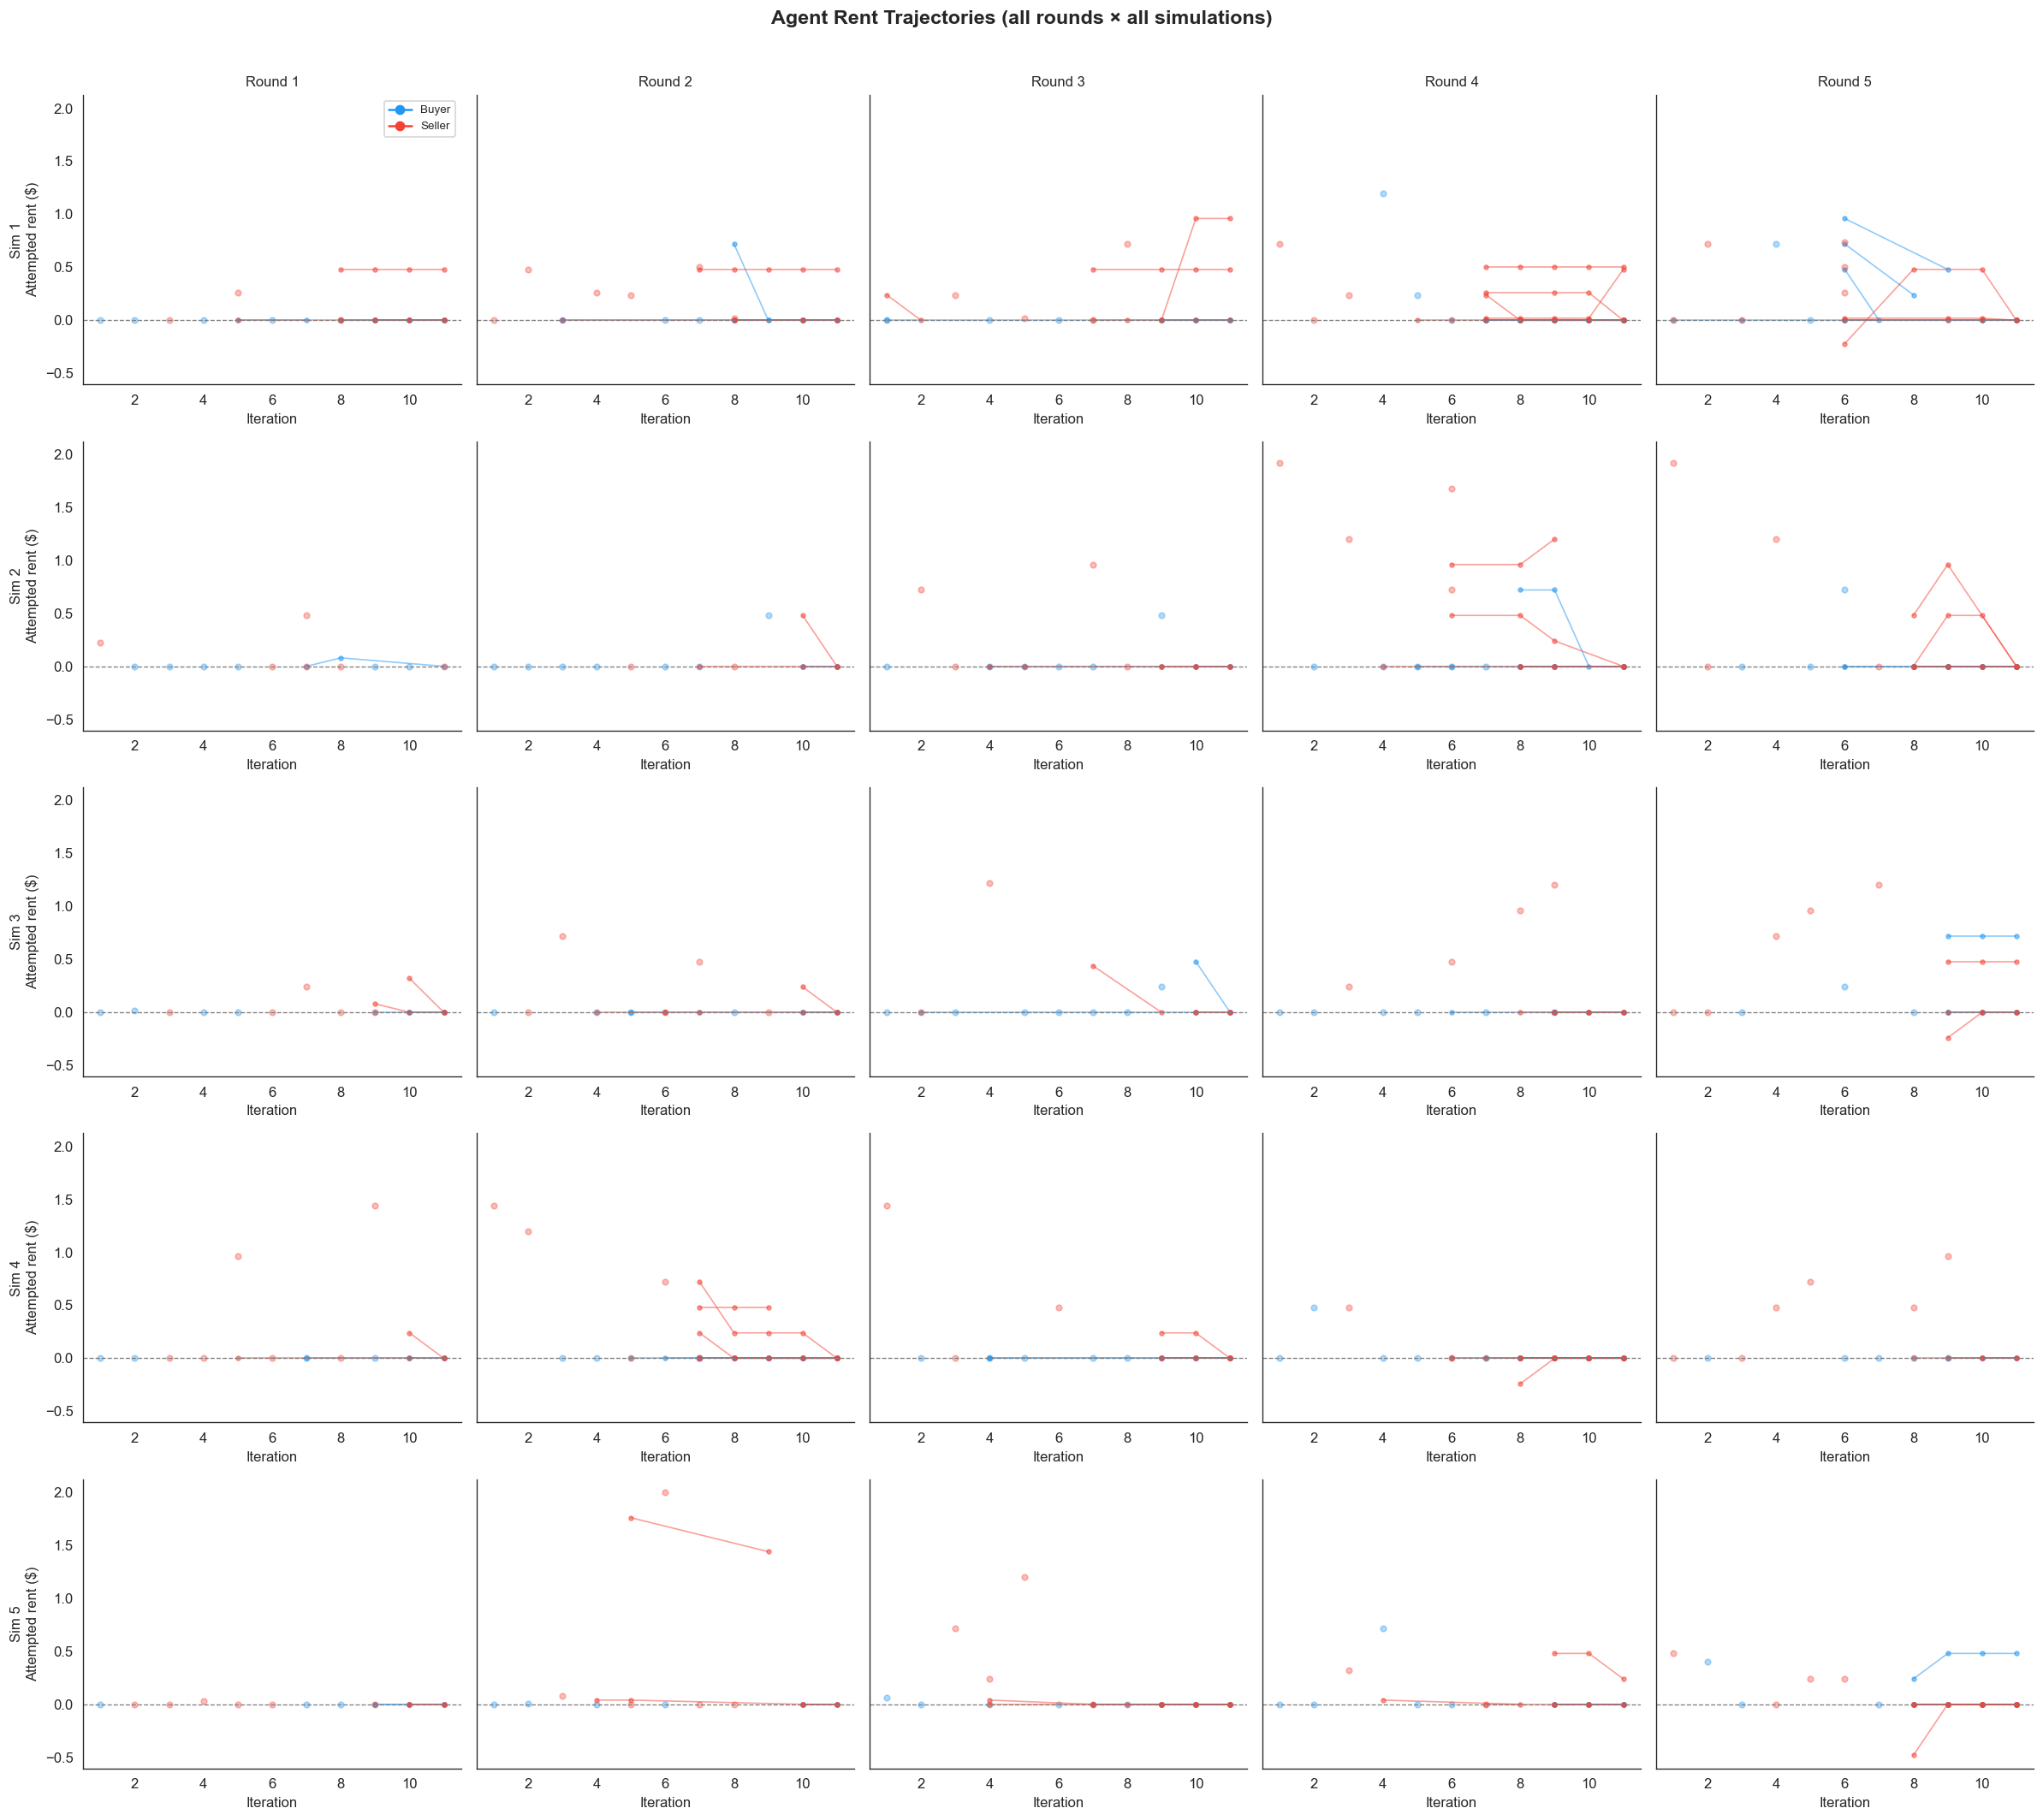

In [409]:
# ============================================================
# CELL 5d — Agent rent trajectories across all rounds and sims
# ============================================================

sims = sorted(ann['sim'].unique())
rounds = sorted(ann['round'].unique())
n_sims = len(sims)
n_rounds = len(rounds)

fig, axes = plt.subplots(n_sims, n_rounds, figsize=(4 * n_rounds, 3.5 * n_sims),
                         sharey=True)

for row, s in enumerate(sims):
    for col, rnd in enumerate(rounds):
        ax = axes[row, col]
        agents_ex = ann[(ann['sim'] == s) & (ann['round'] == rnd)]
        for agent, grp in agents_ex.groupby('announcing_agent_id'):
            grp = grp.sort_values('iteration')
            side = grp['side'].iloc[0]
            color = '#2196F3' if side == 'buyer' else '#F44336'
            if len(grp) == 1:
                ax.plot(grp['iteration'].values[0], grp['attempted_rent'].values[0],
                        'o', color=color, alpha=0.35, markersize=4)
            else:
                ax.plot(grp['iteration'], grp['attempted_rent'],
                        '-o', color=color, alpha=0.5, markersize=3, lw=1.0)
        ax.axhline(0, color='grey', ls='--', lw=0.8)
        if row == 0:
            ax.set_title(f'Round {rnd}', fontsize=10)
        ax.set_xlabel('Iteration')
        if col == 0:
            ax.set_ylabel(f'Sim {s}\nAttempted rent ($)')

axes[0, 0].legend(handles=[
    Line2D([0], [0], color='#2196F3', marker='o', label='Buyer'),
    Line2D([0], [0], color='#F44336', marker='o', label='Seller'),
], fontsize=8)

fig.suptitle('Agent Rent Trajectories (all rounds × all simulations)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

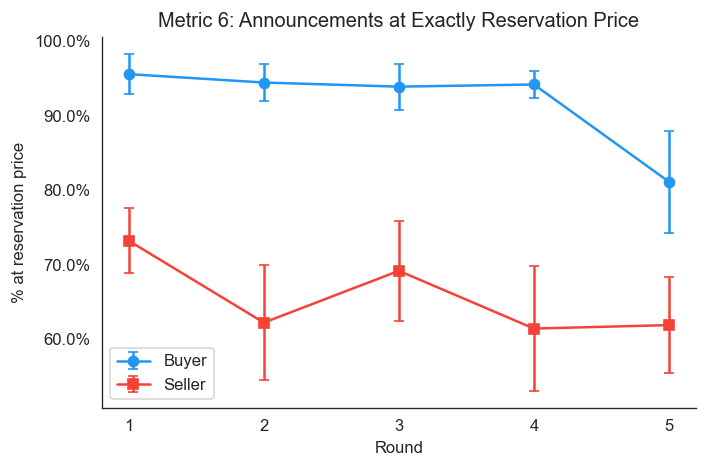

In [410]:
# METRIC 6
# % of announcements at exactly reservation price, by round (mean ± SEM across sims)
fig, ax = plt.subplots(figsize=(6, 4))
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sr = (ann[ann['side'] == side]
          .groupby(['sim', 'round'])
          .apply(lambda g: (g['attempted_rent'] == 0).mean())
          .reset_index(name='pct_at_res'))
    agg = sr.groupby('round')['pct_at_res'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.set_xlabel('Round')
ax.set_ylabel('% at reservation price')
ax.set_title('Metric 6: Announcements at Exactly Reservation Price')
ax.set_xticks(sorted(ann['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

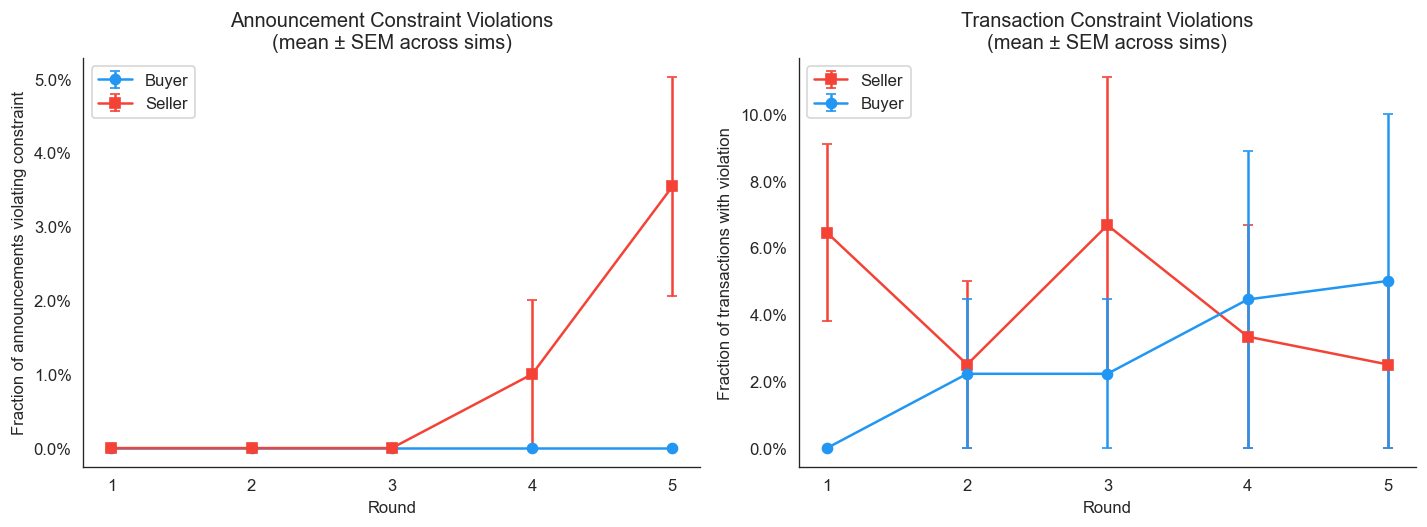


--- Announcement violations ---
Total: 4 / 736 (0.5%)
side
seller    4

--- Transaction violations ---
Seller violations: 9 / 207 (4.3%)
Buyer violations: 6 / 207 (2.9%)


In [411]:
# ============================================================
# Metric: Constraint Violation Rate
#   Fraction of announcements where an agent announces beyond
#   their reservation price (seller asks below, buyer bids above).
#   Also tracks violations in completed transactions.
# ============================================================

ann['violation'] = ann['attempted_rent'] < 0

# Announcement-level violations by round
ann_viol = (ann.groupby(['sim', 'round', 'side'])
            .agg(n_total=('violation', 'count'),
                 n_violations=('violation', 'sum'))
            .reset_index())
ann_viol['violation_rate'] = ann_viol['n_violations'] / ann_viol['n_total']

# Transaction-level violations
tx['seller_rent_check'] = np.where(
    tx['announcement_type'] == 'sell',
    tx['price'] - tx['announcing_agent_reservation_price'],
    tx['price'] - tx['responding_agent_reservation_price'])
tx['buyer_rent_check'] = np.where(
    tx['announcement_type'] == 'buy',
    tx['announcing_agent_reservation_price'] - tx['price'],
    tx['responding_agent_reservation_price'] - tx['price'])
tx['seller_violation'] = tx['seller_rent_check'] < 0
tx['buyer_violation'] = tx['buyer_rent_check'] < 0

tx_viol = tx.groupby(['sim', 'round']).agg(
    n_tx=('seller_violation', 'count'),
    n_seller_viol=('seller_violation', 'sum'),
    n_buyer_viol=('buyer_violation', 'sum'),
).reset_index()
tx_viol['seller_viol_rate'] = tx_viol['n_seller_viol'] / tx_viol['n_tx']
tx_viol['buyer_viol_rate'] = tx_viol['n_buyer_viol'] / tx_viol['n_tx']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Announcement violations
ax = axes[0]
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sub = ann_viol[ann_viol['side'] == side]
    agg = sub.groupby('round')['violation_rate'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.set_xlabel('Round')
ax.set_ylabel('Fraction of announcements violating constraint')
ax.set_title('Announcement Constraint Violations\n(mean ± SEM across sims)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

# Transaction violations
ax = axes[1]
for col, color, marker, label in [('seller_viol_rate', '#F44336', 's', 'Seller'),
                                    ('buyer_viol_rate', '#2196F3', 'o', 'Buyer')]:
    agg = tx_viol.groupby('round')[col].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=label)
ax.set_xlabel('Round')
ax.set_ylabel('Fraction of transactions with violation')
ax.set_title('Transaction Constraint Violations\n(mean ± SEM across sims)')
ax.set_xticks(sorted(tx['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

plt.tight_layout()
plt.show()

# Summary
total_ann = len(ann)
total_viol = ann['violation'].sum()
print(f'\n--- Announcement violations ---')
print(f'Total: {total_viol} / {total_ann} ({total_viol/total_ann:.1%})')
print(ann[ann['violation']].groupby('side').size().to_string())

total_tx = len(tx)
print(f'\n--- Transaction violations ---')
print(f'Seller violations: {tx["seller_violation"].sum()} / {total_tx} ({tx["seller_violation"].mean():.1%})')
print(f'Buyer violations: {tx["buyer_violation"].sum()} / {total_tx} ({tx["buyer_violation"].mean():.1%})')

# Miscellaneous

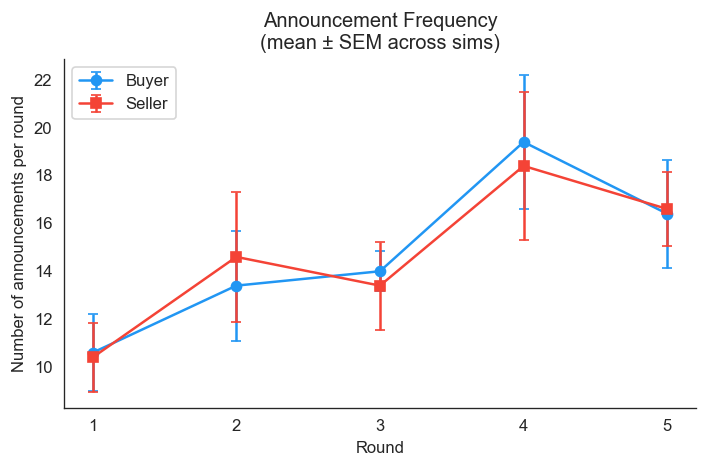


--- Announcement counts by round and side ---
              count  mean  std   min   25%   50%   75%   max
side   round                                                
buyer  1        5.0  10.6  3.6   9.0   9.0   9.0   9.0  17.0
       2        5.0  13.4  5.1   8.0  11.0  11.0  16.0  21.0
       3        5.0  14.0  1.9  12.0  13.0  13.0  16.0  16.0
       4        5.0  19.4  6.3  13.0  14.0  19.0  23.0  28.0
       5        5.0  16.4  5.0  10.0  12.0  19.0  20.0  21.0
seller 1        5.0  10.4  3.2   6.0  10.0  10.0  11.0  15.0
       2        5.0  14.6  6.1   7.0  12.0  13.0  18.0  23.0
       3        5.0  13.4  4.1   8.0  12.0  12.0  17.0  18.0
       4        5.0  18.4  6.9  11.0  14.0  18.0  20.0  29.0
       5        5.0  16.6  3.4  12.0  14.0  18.0  19.0  20.0


In [412]:
# ============================================================
# Metric: Announcement Frequency
#   How many announcements are made per round?
#   A declining count suggests agents need fewer attempts to transact.
# ============================================================

ann_counts = (ann.groupby(['sim', 'round', 'side'])
              .size().reset_index(name='n_announcements'))

fig, ax = plt.subplots(figsize=(6, 4))
for side, color, marker in [('buyer', '#2196F3', 'o'), ('seller', '#F44336', 's')]:
    sub = ann_counts[ann_counts['side'] == side]
    agg = sub.groupby('round')['n_announcements'].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=side.title())
ax.set_xlabel('Round')
ax.set_ylabel('Number of announcements per round')
ax.set_title('Announcement Frequency\n(mean ± SEM across sims)')
ax.set_xticks(sorted(ann['round'].unique()))
ax.legend()
plt.tight_layout()
plt.show()

print('\n--- Announcement counts by round and side ---')
print(ann_counts.groupby(['side', 'round'])['n_announcements'].describe().round(1).to_string())

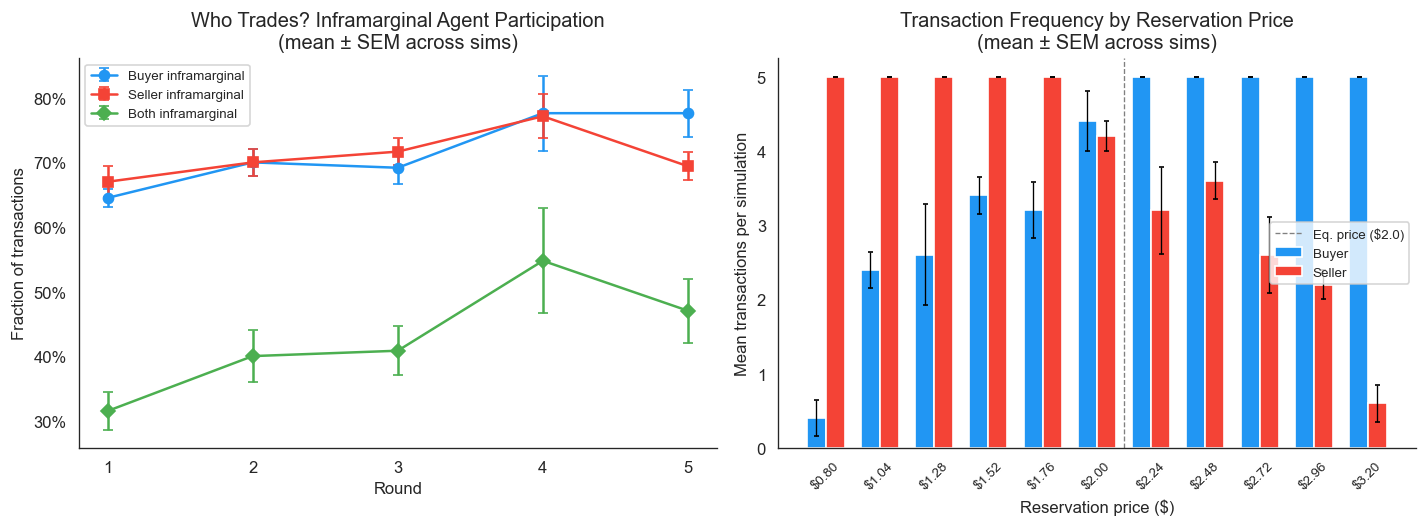


--- Who trades summary ---
Transactions with inframarginal buyer: 71.0%
Transactions with inframarginal seller: 70.5%
Transactions with both inframarginal: 41.5%

--- Extramarginal agents who traded ---
Extramarginal buyers (res < $2.0): 60 transactions
 sim  round  iteration  buyer_res  price
   1      1          1       1.28   1.28
   1      1          2       1.76   1.76
   1      1          7       1.04   1.04
   1      2          3       1.04   1.04
   1      2          5       1.52   1.52
   1      3          1       1.04   1.04
   1      3          8       1.52   1.52
   1      5          1       1.76   1.52
   1      5          5       1.52   1.52
   2      1          3       0.80   0.80
   2      1          4       1.76   1.76
   2      1          5       1.04   1.04
   2      1          9       1.52   1.52
   2      2          2       1.28   1.28
   2      2          3       1.04   1.04
   2      2          6       1.52   1.52
   2      3          3       1.28   1.28
   2   

In [413]:
# ============================================================
# Metric: Who Trades?
#   In equilibrium, the 6 lowest-cost sellers and 6 highest-value
#   buyers should trade. Are the right agents transacting?
# ============================================================

# Sellers who should trade: reservation price <= eq_price (the 6 cheapest)
inframarginal_seller_res = set(supply[:q_eq])
# Buyers who should trade: reservation price >= eq_price (the 6 highest-value)
inframarginal_buyer_res = set(demand[:q_eq])

# Identify buyer and seller reservation prices in each transaction
tx['buyer_res'] = np.where(
    tx['announcement_type'] == 'buy',
    tx['announcing_agent_reservation_price'],
    tx['responding_agent_reservation_price'])
tx['seller_res'] = np.where(
    tx['announcement_type'] == 'sell',
    tx['announcing_agent_reservation_price'],
    tx['responding_agent_reservation_price'])

tx['buyer_inframarginal'] = tx['buyer_res'] >= p_eq
tx['seller_inframarginal'] = tx['seller_res'] <= p_eq
tx['both_inframarginal'] = tx['buyer_inframarginal'] & tx['seller_inframarginal']

# Aggregate by round
tx_who = tx.groupby(['sim', 'round']).agg(
    n_tx=('both_inframarginal', 'count'),
    n_buyer_infra=('buyer_inframarginal', 'sum'),
    n_seller_infra=('seller_inframarginal', 'sum'),
    n_both_infra=('both_inframarginal', 'sum'),
).reset_index()
tx_who['pct_buyer_infra'] = tx_who['n_buyer_infra'] / tx_who['n_tx']
tx_who['pct_seller_infra'] = tx_who['n_seller_infra'] / tx_who['n_tx']
tx_who['pct_both_infra'] = tx_who['n_both_infra'] / tx_who['n_tx']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Fraction of transactions involving inframarginal agents
ax = axes[0]
for col, color, marker, label in [('pct_buyer_infra', '#2196F3', 'o', 'Buyer inframarginal'),
                                    ('pct_seller_infra', '#F44336', 's', 'Seller inframarginal'),
                                    ('pct_both_infra', '#4CAF50', 'D', 'Both inframarginal')]:
    agg = tx_who.groupby('round')[col].agg(['mean', 'sem'])
    ax.errorbar(agg.index, agg['mean'], yerr=agg['sem'],
                fmt=f'-{marker}', color=color, capsize=3, label=label)
ax.set_xlabel('Round')
ax.set_ylabel('Fraction of transactions')
ax.set_title('Who Trades? Inframarginal Agent Participation\n(mean ± SEM across sims)')
ax.set_xticks(sorted(tx['round'].unique()))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)

# Which reservation prices actually trade? (mean ± SEM across sims)
ax = axes[1]
all_res = np.sort(np.union1d(supply, demand))
x = np.arange(len(all_res))
width = 0.35
sims = sorted(tx['sim'].unique())

for col, color, offset, label in [('buyer_res', '#2196F3', -width/2, 'Buyer'),
                                    ('seller_res', '#F44336', width/2, 'Seller')]:
    counts = np.zeros((len(sims), len(all_res)))
    for i, s in enumerate(sims):
        res_counts = tx[tx['sim'] == s][col].value_counts()
        for j, r in enumerate(all_res):
            counts[i, j] = res_counts.get(r, 0)
    mean_counts = counts.mean(axis=0)
    sem_counts = counts.std(axis=0, ddof=1) / np.sqrt(len(sims))
    ax.bar(x + offset, mean_counts, width, color=color, edgecolor='white', label=label)
    ax.errorbar(x + offset, mean_counts, yerr=sem_counts,
                fmt='none', ecolor='black', capsize=1.5, lw=0.8)

eq_idx = np.argmin(np.abs(all_res - p_eq))
ax.axvline(x=eq_idx + 0.5, color='grey', ls='--', lw=0.8,
           label=f'Eq. price (${p_eq})')
ax.set_xticks(x)
ax.set_xticklabels([f'${r:.2f}' for r in all_res], rotation=45, fontsize=8)
ax.set_xlabel('Reservation price ($)')
ax.set_ylabel('Mean transactions per simulation')
ax.set_title('Transaction Frequency by Reservation Price\n(mean ± SEM across sims)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary
print('\n--- Who trades summary ---')
print(f'Transactions with inframarginal buyer: {tx["buyer_inframarginal"].mean():.1%}')
print(f'Transactions with inframarginal seller: {tx["seller_inframarginal"].mean():.1%}')
print(f'Transactions with both inframarginal: {tx["both_inframarginal"].mean():.1%}')
print(f'\n--- Extramarginal agents who traded ---')
extra_buyers = tx[~tx['buyer_inframarginal']][['sim', 'round', 'iteration', 'buyer_res', 'price']]
extra_sellers = tx[~tx['seller_inframarginal']][['sim', 'round', 'iteration', 'seller_res', 'price']]
print(f'Extramarginal buyers (res < ${p_eq}): {len(extra_buyers)} transactions')
if len(extra_buyers) > 0:
    print(extra_buyers.to_string(index=False))
print(f'\nExtramarginal sellers (res > ${p_eq}): {len(extra_sellers)} transactions')
if len(extra_sellers) > 0:
    print(extra_sellers.to_string(index=False))

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


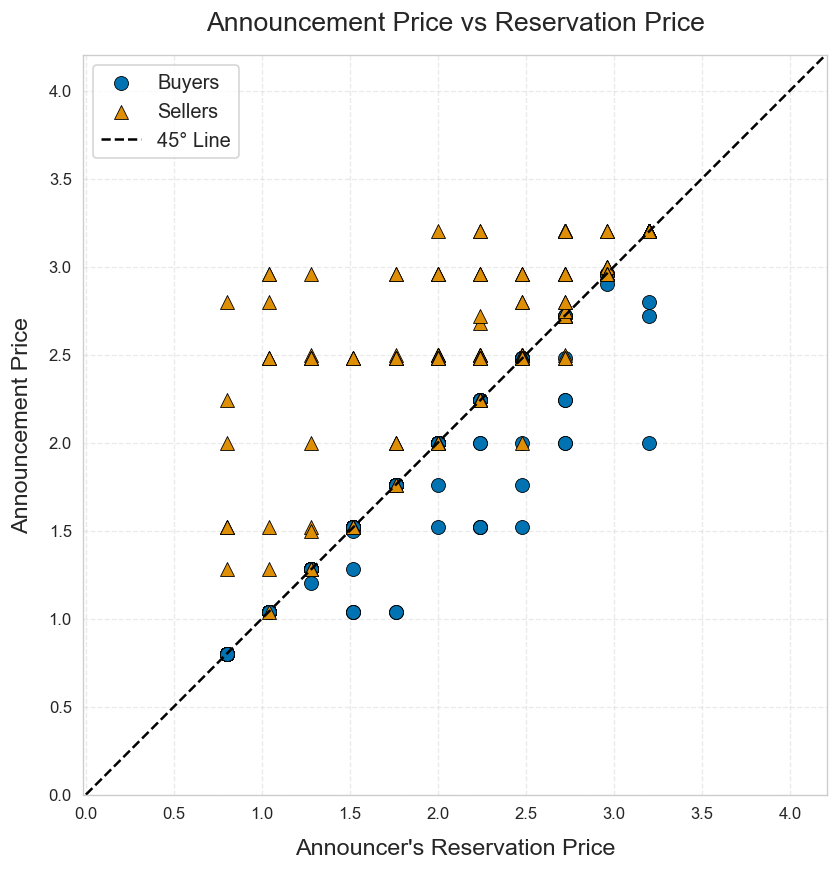

In [414]:
# Plot the announcement price vs reservation price by agent type


with sns.axes_style("whitegrid"):

    # set up figure
    plt.figure(figsize=(8, 8))

    # colors (colorblind-friendly)
    buyer_color = sns.color_palette("colorblind")[0]  # blue
    seller_color = sns.color_palette("colorblind")[1]  # orange

    # scatter plots
    plt.scatter(
        df_announcements.loc[buy_mask, 'announcing_agent_reservation_price'],
        df_announcements.loc[buy_mask, 'price'],
        color=buyer_color, label='Buyers', 
        edgecolor='k', s=70, linewidth=0.5, marker='o'
    )

    plt.scatter(
        df_announcements.loc[sell_mask, 'announcing_agent_reservation_price'],
        df_announcements.loc[sell_mask, 'price'],
        color=seller_color, label='Sellers',
        edgecolor='k', s=70, linewidth=0.5, marker='^'
    )

    # 45-degree line (using supply/demand limits)
    min_val = np.max([np.concat([supply, demand]).min() - 1, 0])
    max_val = np.concat([supply, demand]).max() + 1

    plt.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='45° Line')

    # labels and formatting
    plt.xlabel("Announcer's Reservation Price", fontsize=14, labelpad=10)
    plt.ylabel("Announcement Price", fontsize=14, labelpad=10)
    plt.title("Announcement Price vs Reservation Price", fontsize=16, pad=15)
    plt.legend(frameon=True, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)

    # make axes square (for true 45° comparison)
    plt.axis('equal')

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)